# 🛰️ AFETSONAR — Notebook 2_v3 Phase 1: Building Localization

**Calamitas AI · Teknofest 2025 · İki Aşamalı Eğitim · Aşama 1/2**

---

## 📌 Bu Notebook Ne Yapıyor?

xView2 challenge kazananlarının kullandığı **iki aşamalı eğitim** yaklaşımının **ilk aşaması**. Burada modele tek bir basit görev öğretiyoruz:

> **"Bu görüntüde nerede bina var, nerede yok?"**

Hasar derecesi yok, sadece **binary segmentation**: bina var (1) vs arka plan (0).

### Neden iki aşama?

Damage classification (6 sınıf, %0.05-0.5 dağılım) çok zor bir görev. Modelimizin önce **kolay görevle** ısınması gerek:

1. **Phase 1 (BU NOTEBOOK):** Binary "bina var/yok"
   - Sınıf dağılımı dengeli (~%6 bina, %94 background)
   - Modelin pre-disaster görüntülerden bina sınırlarını öğrenmesi kolay
   - SegFormer bu konuda çok başarılı (mIoU 0.85+ tipik)
   
2. **Phase 2 (sonraki notebook):** Damage classification
   - Phase 1'in encoder weights'inden başlayacak
   - Encoder zaten "bina nedir" biliyor → fine-tune çok daha hızlı convergence
   - Model dikkatini hasar seviyesine odaklayabilir

Bu yaklaşım xView2 challenge'da en iyi sonuçları veren strateji.

### Bu notebook ne kullanıyor?

**Input:** Pre-disaster image [B, 3, H, W]
**Output:** Binary mask [B, 2, H, W] — bg vs building
**Loss:** 0.5 * BCE + 0.5 * Dice (basit, dengeli)
**Model:** SegFormer-B3 (~45M param)
**Resolution:** 768x768 (önceki 512'den artırıldı)
**Süre:** ~2-3 saat (H100'de)
**Hedef:** Binary IoU ≥ 0.85

### Neden 768 resolution?

xBD görüntüleri 1024x1024. 512'ye crop ederken bilgi kaybediyorduk. 768 orta yol — daha çok detay, kabul edilebilir bellek.

### Sonraki adım

Bu notebook bittiğinde Drive'da `localizer_best.pth` olacak. Phase 2 notebook'u bu dosyayı yükleyip encoder weights'ini kopyalayacak.

---

## 1️⃣ Drive + GPU

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os

PROJECT_ROOT = "/content/drive/MyDrive/AFETSONAR"
DATA_RAW     = os.path.join(PROJECT_ROOT, "data/raw/xview2")
DATA_MASKS   = os.path.join(PROJECT_ROOT, "data/processed/masks")
DATA_SPLITS  = os.path.join(PROJECT_ROOT, "data/splits")
SRC_DIR      = os.path.join(PROJECT_ROOT, "src")
CKPT_TEACHER = os.path.join(PROJECT_ROOT, "checkpoints/teacher")
OUTPUTS_VIZ  = os.path.join(PROJECT_ROOT, "outputs/visualizations")

# Sanity check
required = {
    "train_v2.csv": os.path.join(DATA_SPLITS, "train_v2.csv"),
    "val_v2.csv":   os.path.join(DATA_SPLITS, "val_v2.csv"),
}

print("✅ Drive bağlandı")
print()
for name, path in required.items():
    marker = "✅" if os.path.exists(path) else "❌"
    print(f"  {marker} {name}")

if not all(os.path.exists(p) for p in required.values()):
    raise FileNotFoundError("Notebook 1b çıktıları eksik!")

os.makedirs(CKPT_TEACHER, exist_ok=True)
os.makedirs(OUTPUTS_VIZ, exist_ok=True)

# === GPU ===
import torch

print("\n⚙️  Donanım:")
gpu_name = torch.cuda.get_device_name(0)
vram_gb = round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 1)
bf16_supported = torch.cuda.is_bf16_supported()

print(f"  GPU: {gpu_name}")
print(f"  VRAM: {vram_gb} GB")

# Phase 1 single image (3ch), so daha büyük batch alabilir
if "H100" in gpu_name:
    BATCH_SIZE = 16
    GRAD_ACCUM_STEPS = 2  # efektif 32
    NUM_WORKERS = 8
elif "A100" in gpu_name:
    BATCH_SIZE = 12
    GRAD_ACCUM_STEPS = 2
    NUM_WORKERS = 6
elif "L4" in gpu_name or "V100" in gpu_name:
    BATCH_SIZE = 8
    GRAD_ACCUM_STEPS = 4
    NUM_WORKERS = 4
elif "T4" in gpu_name:
    BATCH_SIZE = 4
    GRAD_ACCUM_STEPS = 8
    NUM_WORKERS = 2
else:
    BATCH_SIZE = 8
    GRAD_ACCUM_STEPS = 4
    NUM_WORKERS = 4

EFFECTIVE_BATCH = BATCH_SIZE * GRAD_ACCUM_STEPS
PRECISION = "bf16" if bf16_supported else "fp16"
device = torch.device("cuda")

# Phase 1: 768 resolution (önceki 512'den artırıldı)
IMAGE_SIZE = 768

print(f"\n📊 Ayarlar (Phase 1: Localization):")
print(f"  micro batch     = {BATCH_SIZE}")
print(f"  grad accum      = {GRAD_ACCUM_STEPS}")
print(f"  effective batch = {EFFECTIVE_BATCH}")
print(f"  image size      = {IMAGE_SIZE}")
print(f"  precision       = {PRECISION}")

Mounted at /content/drive
✅ Drive bağlandı

  ✅ train_v2.csv
  ✅ val_v2.csv

⚙️  Donanım:
  GPU: NVIDIA H100 80GB HBM3
  VRAM: 79.2 GB

📊 Ayarlar (Phase 1: Localization):
  micro batch     = 16
  grad accum      = 2
  effective batch = 32
  image size      = 768
  precision       = bf16


## 2️⃣ v3 Modüllerini Yaz

`models_v3.py` (LocalizerSegformer + SiameseTeacherSegformerV3) ve `losses_v3.py` (LocalizationLoss + Lovász)

In [2]:
import os
import base64

MODELS_PY = base64.b64decode("IiIiCkFGRVRTT05BUiBNb2RlbHMgdjMuCgpUd28gbW9kZWwgY2xhc3NlczoKLSBMb2NhbGl6ZXJTZWdmb3JtZXI6IFBoYXNlIDEsIGJpbmFyeSBidWlsZGluZyBsb2NhbGl6YXRpb24KLSBTaWFtZXNlVGVhY2hlclNlZ2Zvcm1lclYzOiBQaGFzZSAyLCBkYW1hZ2UgY2xhc3NpZmljYXRpb24gd2l0aCBkZWVwIHN1cGVydmlzaW9uCiIiIgoKaW1wb3J0IHRvcmNoCmltcG9ydCB0b3JjaC5ubiBhcyBubgppbXBvcnQgdG9yY2gubm4uZnVuY3Rpb25hbCBhcyBGCmZyb20gdHJhbnNmb3JtZXJzIGltcG9ydCBTZWdmb3JtZXJGb3JTZW1hbnRpY1NlZ21lbnRhdGlvbiwgU2VnZm9ybWVyQ29uZmlnCgoKY2xhc3MgTG9jYWxpemVyU2VnZm9ybWVyKG5uLk1vZHVsZSk6CiAgICBkZWYgX19pbml0X18oCiAgICAgICAgc2VsZiwKICAgICAgICBiYWNrYm9uZV9uYW1lPSJudmlkaWEvc2VnZm9ybWVyLWIzLWZpbmV0dW5lZC1hZGUtNTEyLTUxMiIsCiAgICAgICAgcHJldHJhaW5lZD1UcnVlLAogICAgKToKICAgICAgICBzdXBlcigpLl9faW5pdF9fKCkKICAgICAgICBpZiBwcmV0cmFpbmVkOgogICAgICAgICAgICBzZWxmLnNlZ2Zvcm1lciA9IFNlZ2Zvcm1lckZvclNlbWFudGljU2VnbWVudGF0aW9uLmZyb21fcHJldHJhaW5lZCgKICAgICAgICAgICAgICAgIGJhY2tib25lX25hbWUsCiAgICAgICAgICAgICAgICBudW1fbGFiZWxzPTIsCiAgICAgICAgICAgICAgICBpZ25vcmVfbWlzbWF0Y2hlZF9zaXplcz1UcnVlLAogICAgICAgICAgICApCiAgICAgICAgZWxzZToKICAgICAgICAgICAgY29uZmlnID0gU2VnZm9ybWVyQ29uZmlnLmZyb21fcHJldHJhaW5lZChiYWNrYm9uZV9uYW1lKQogICAgICAgICAgICBjb25maWcubnVtX2xhYmVscyA9IDIKICAgICAgICAgICAgc2VsZi5zZWdmb3JtZXIgPSBTZWdmb3JtZXJGb3JTZW1hbnRpY1NlZ21lbnRhdGlvbihjb25maWcpCgogICAgZGVmIGZvcndhcmQoc2VsZiwgeCk6CiAgICAgICAgQiwgQywgSCwgVyA9IHguc2hhcGUKICAgICAgICBvdXRwdXRzID0gc2VsZi5zZWdmb3JtZXIoeCkKICAgICAgICBsb2dpdHMgPSBvdXRwdXRzLmxvZ2l0cwogICAgICAgIGxvZ2l0cyA9IEYuaW50ZXJwb2xhdGUobG9naXRzLCBzaXplPShILCBXKSwgbW9kZT0iYmlsaW5lYXIiLCBhbGlnbl9jb3JuZXJzPUZhbHNlKQogICAgICAgIHJldHVybiBsb2dpdHMKCiAgICBkZWYgZ2V0X2VuY29kZXJfc3RhdGVfZGljdChzZWxmKToKICAgICAgICBlbmNvZGVyX3N0YXRlID0ge30KICAgICAgICBmb3IgbmFtZSwgcGFyYW0gaW4gc2VsZi5zZWdmb3JtZXIuc2VnZm9ybWVyLmVuY29kZXIuc3RhdGVfZGljdCgpLml0ZW1zKCk6CiAgICAgICAgICAgIGVuY29kZXJfc3RhdGVbbmFtZV0gPSBwYXJhbQogICAgICAgIHJldHVybiBlbmNvZGVyX3N0YXRlCgogICAgZGVmIGVuYWJsZV9ncmFkaWVudF9jaGVja3BvaW50aW5nKHNlbGYpOgogICAgICAgIGlmIGhhc2F0dHIoc2VsZi5zZWdmb3JtZXIuc2VnZm9ybWVyLmVuY29kZXIsICJncmFkaWVudF9jaGVja3BvaW50aW5nX2VuYWJsZSIpOgogICAgICAgICAgICBzZWxmLnNlZ2Zvcm1lci5zZWdmb3JtZXIuZW5jb2Rlci5ncmFkaWVudF9jaGVja3BvaW50aW5nX2VuYWJsZSgpCiAgICAgICAgICAgIHJldHVybiBUcnVlCiAgICAgICAgcmV0dXJuIEZhbHNlCgogICAgZGVmIG51bV9wYXJhbWV0ZXJzKHNlbGYpOgogICAgICAgIHJldHVybiBzdW0ocC5udW1lbCgpIGZvciBwIGluIHNlbGYucGFyYW1ldGVycygpIGlmIHAucmVxdWlyZXNfZ3JhZCkKCgpjbGFzcyBTaWFtZXNlVGVhY2hlclNlZ2Zvcm1lclYzKG5uLk1vZHVsZSk6CiAgICBkZWYgX19pbml0X18oCiAgICAgICAgc2VsZiwKICAgICAgICBiYWNrYm9uZV9uYW1lPSJudmlkaWEvc2VnZm9ybWVyLWIzLWZpbmV0dW5lZC1hZGUtNTEyLTUxMiIsCiAgICAgICAgbnVtX2RhbWFnZV9jbGFzc2VzPTYsCiAgICAgICAgbnVtX2Rpc2FzdGVyX2NsYXNzZXM9NSwKICAgICAgICBwcmV0cmFpbmVkPVRydWUsCiAgICAgICAgdXNlX2RlZXBfc3VwZXJ2aXNpb249VHJ1ZSwKICAgICk6CiAgICAgICAgc3VwZXIoKS5fX2luaXRfXygpCiAgICAgICAgc2VsZi5udW1fZGFtYWdlX2NsYXNzZXMgPSBudW1fZGFtYWdlX2NsYXNzZXMKICAgICAgICBzZWxmLm51bV9kaXNhc3Rlcl9jbGFzc2VzID0gbnVtX2Rpc2FzdGVyX2NsYXNzZXMKICAgICAgICBzZWxmLnVzZV9kZWVwX3N1cGVydmlzaW9uID0gdXNlX2RlZXBfc3VwZXJ2aXNpb24KCiAgICAgICAgaWYgcHJldHJhaW5lZDoKICAgICAgICAgICAgYmFzZV9tb2RlbCA9IFNlZ2Zvcm1lckZvclNlbWFudGljU2VnbWVudGF0aW9uLmZyb21fcHJldHJhaW5lZCgKICAgICAgICAgICAgICAgIGJhY2tib25lX25hbWUsCiAgICAgICAgICAgICAgICBudW1fbGFiZWxzPW51bV9kYW1hZ2VfY2xhc3NlcywKICAgICAgICAgICAgICAgIGlnbm9yZV9taXNtYXRjaGVkX3NpemVzPVRydWUsCiAgICAgICAgICAgICkKICAgICAgICBlbHNlOgogICAgICAgICAgICBjb25maWcgPSBTZWdmb3JtZXJDb25maWcuZnJvbV9wcmV0cmFpbmVkKGJhY2tib25lX25hbWUpCiAgICAgICAgICAgIGNvbmZpZy5udW1fbGFiZWxzID0gbnVtX2RhbWFnZV9jbGFzc2VzCiAgICAgICAgICAgIGJhc2VfbW9kZWwgPSBTZWdmb3JtZXJGb3JTZW1hbnRpY1NlZ21lbnRhdGlvbihjb25maWcpCgogICAgICAgIHNlbGYuZW5jb2RlciA9IGJhc2VfbW9kZWwuc2VnZm9ybWVyLmVuY29kZXIKICAgICAgICBzZWxmLmRlY29kZV9oZWFkID0gYmFzZV9tb2RlbC5kZWNvZGVfaGVhZAoKICAgICAgICBlbmNvZGVyX2NoYW5uZWxzID0gYmFzZV9tb2RlbC5jb25maWcuaGlkZGVuX3NpemVzICAjIFs2NCwgMTI4LCAzMjAsIDUxMl0KICAgICAgICBzZWxmLmVuY29kZXJfY2hhbm5lbHMgPSBlbmNvZGVyX2NoYW5uZWxzCgogICAgICAgIHNlbGYuZnVzaW9uX2NvbnZzID0gbm4uTW9kdWxlTGlzdChbCiAgICAgICAgICAgIG5uLlNlcXVlbnRpYWwoCiAgICAgICAgICAgICAgICBubi5Db252MmQoY2ggKiAzLCBjaCwga2VybmVsX3NpemU9MSwgYmlhcz1GYWxzZSksCiAgICAgICAgICAgICAgICBubi5CYXRjaE5vcm0yZChjaCksCiAgICAgICAgICAgICAgICBubi5SZUxVKGlucGxhY2U9VHJ1ZSksCiAgICAgICAgICAgICkKICAgICAgICAgICAgZm9yIGNoIGluIGVuY29kZXJfY2hhbm5lbHMKICAgICAgICBdKQoKICAgICAgICBpZiB1c2VfZGVlcF9zdXBlcnZpc2lvbjoKICAgICAgICAgICAgc2VsZi5hdXhfaGVhZHMgPSBubi5Nb2R1bGVMaXN0KFsKICAgICAgICAgICAgICAgIG5uLlNlcXVlbnRpYWwoCiAgICAgICAgICAgICAgICAgICAgbm4uQ29udjJkKGNoLCBjaCAvLyAyLCBrZXJuZWxfc2l6ZT0zLCBwYWRkaW5nPTEpLAogICAgICAgICAgICAgICAgICAgIG5uLkJhdGNoTm9ybTJkKGNoIC8vIDIpLAogICAgICAgICAgICAgICAgICAgIG5uLlJlTFUoaW5wbGFjZT1UcnVlKSwKICAgICAgICAgICAgICAgICAgICBubi5Ecm9wb3V0MmQoMC4xKSwKICAgICAgICAgICAgICAgICAgICBubi5Db252MmQoY2ggLy8gMiwgbnVtX2RhbWFnZV9jbGFzc2VzLCBrZXJuZWxfc2l6ZT0xKSwKICAgICAgICAgICAgICAgICkKICAgICAgICAgICAgICAgIGZvciBjaCBpbiBlbmNvZGVyX2NoYW5uZWxzWzotMV0KICAgICAgICAgICAgXSkKICAgICAgICBlbHNlOgogICAgICAgICAgICBzZWxmLmF1eF9oZWFkcyA9IE5vbmUKCiAgICAgICAgbGFzdF9kaW0gPSBlbmNvZGVyX2NoYW5uZWxzWy0xXQogICAgICAgIHNlbGYuY2hhbmdlX2hlYWQgPSBubi5TZXF1ZW50aWFsKAogICAgICAgICAgICBubi5Db252MmQobGFzdF9kaW0sIDI1Niwga2VybmVsX3NpemU9MywgcGFkZGluZz0xKSwKICAgICAgICAgICAgbm4uQmF0Y2hOb3JtMmQoMjU2KSwKICAgICAgICAgICAgbm4uUmVMVShpbnBsYWNlPVRydWUpLAogICAgICAgICAgICBubi5Ecm9wb3V0MmQoMC4xKSwKICAgICAgICAgICAgbm4uQ29udjJkKDI1NiwgMiwga2VybmVsX3NpemU9MSksCiAgICAgICAgKQoKICAgICAgICBzZWxmLmRpc2FzdGVyX2hlYWQgPSBubi5TZXF1ZW50aWFsKAogICAgICAgICAgICBubi5BZGFwdGl2ZUF2Z1Bvb2wyZCgxKSwKICAgICAgICAgICAgbm4uRmxhdHRlbigpLAogICAgICAgICAgICBubi5MaW5lYXIobGFzdF9kaW0sIDI1NiksCiAgICAgICAgICAgIG5uLlJlTFUoaW5wbGFjZT1UcnVlKSwKICAgICAgICAgICAgbm4uRHJvcG91dCgwLjMpLAogICAgICAgICAgICBubi5MaW5lYXIoMjU2LCBudW1fZGlzYXN0ZXJfY2xhc3NlcyksCiAgICAgICAgKQoKICAgIGRlZiBfZW5jb2RlKHNlbGYsIHgpOgogICAgICAgIG91dHB1dHMgPSBzZWxmLmVuY29kZXIoeCwgb3V0cHV0X2hpZGRlbl9zdGF0ZXM9VHJ1ZSwgcmV0dXJuX2RpY3Q9VHJ1ZSkKICAgICAgICByZXR1cm4gbGlzdChvdXRwdXRzLmhpZGRlbl9zdGF0ZXMpCgogICAgZGVmIF9mdXNlX2ZlYXR1cmVzKHNlbGYsIGZlYXR1cmVzX3ByZSwgZmVhdHVyZXNfcG9zdCk6CiAgICAgICAgZnVzZWQgPSBbXQogICAgICAgIGZvciBpLCAocHJlLCBwb3N0KSBpbiBlbnVtZXJhdGUoemlwKGZlYXR1cmVzX3ByZSwgZmVhdHVyZXNfcG9zdCkpOgogICAgICAgICAgICBkaWZmID0gdG9yY2guYWJzKHBvc3QgLSBwcmUpCiAgICAgICAgICAgIGNvbWJpbmVkID0gdG9yY2guY2F0KFtwcmUsIHBvc3QsIGRpZmZdLCBkaW09MSkKICAgICAgICAgICAgZnVzZWRfZmVhdCA9IHNlbGYuZnVzaW9uX2NvbnZzW2ldKGNvbWJpbmVkKQogICAgICAgICAgICBmdXNlZC5hcHBlbmQoZnVzZWRfZmVhdCkKICAgICAgICByZXR1cm4gZnVzZWQKCiAgICBkZWYgZm9yd2FyZChzZWxmLCB4KToKICAgICAgICBCLCBDLCBILCBXID0geC5zaGFwZQogICAgICAgIGFzc2VydCBDID09IDYsIGYiRXhwZWN0ZWQgNiBjaGFubmVscywgZ290IHtDfSIKCiAgICAgICAgcHJlID0geFs6LCA6M10KICAgICAgICBwb3N0ID0geFs6LCAzOl0KCiAgICAgICAgZmVhdHVyZXNfcHJlID0gc2VsZi5fZW5jb2RlKHByZSkKICAgICAgICBmZWF0dXJlc19wb3N0ID0gc2VsZi5fZW5jb2RlKHBvc3QpCiAgICAgICAgZnVzZWRfZmVhdHVyZXMgPSBzZWxmLl9mdXNlX2ZlYXR1cmVzKGZlYXR1cmVzX3ByZSwgZmVhdHVyZXNfcG9zdCkKCiAgICAgICAgZGVjb2Rlcl9vdXRwdXQgPSBzZWxmLmRlY29kZV9oZWFkKGZ1c2VkX2ZlYXR1cmVzKQogICAgICAgIGRhbWFnZV9tYWluID0gRi5pbnRlcnBvbGF0ZSgKICAgICAgICAgICAgZGVjb2Rlcl9vdXRwdXQsCiAgICAgICAgICAgIHNpemU9KEgsIFcpLAogICAgICAgICAgICBtb2RlPSJiaWxpbmVhciIsCiAgICAgICAgICAgIGFsaWduX2Nvcm5lcnM9RmFsc2UsCiAgICAgICAgKQoKICAgICAgICBpZiBzZWxmLnVzZV9kZWVwX3N1cGVydmlzaW9uIGFuZCBzZWxmLmF1eF9oZWFkcyBpcyBub3QgTm9uZToKICAgICAgICAgICAgZGFtYWdlX2xvZ2l0c19saXN0ID0gW2RhbWFnZV9tYWluXQogICAgICAgICAgICBmb3IgaSwgYXV4X2hlYWQgaW4gZW51bWVyYXRlKHNlbGYuYXV4X2hlYWRzKToKICAgICAgICAgICAgICAgIGF1eF9sb2dpdHMgPSBhdXhfaGVhZChmdXNlZF9mZWF0dXJlc1tpXSkKICAgICAgICAgICAgICAgIGF1eF9sb2dpdHMgPSBGLmludGVycG9sYXRlKAogICAgICAgICAgICAgICAgICAgIGF1eF9sb2dpdHMsCiAgICAgICAgICAgICAgICAgICAgc2l6ZT0oSCwgVyksCiAgICAgICAgICAgICAgICAgICAgbW9kZT0iYmlsaW5lYXIiLAogICAgICAgICAgICAgICAgICAgIGFsaWduX2Nvcm5lcnM9RmFsc2UsCiAgICAgICAgICAgICAgICApCiAgICAgICAgICAgICAgICBkYW1hZ2VfbG9naXRzX2xpc3QuYXBwZW5kKGF1eF9sb2dpdHMpCiAgICAgICAgICAgIGRhbWFnZV9vdXRwdXQgPSBkYW1hZ2VfbG9naXRzX2xpc3QKICAgICAgICBlbHNlOgogICAgICAgICAgICBkYW1hZ2Vfb3V0cHV0ID0gZGFtYWdlX21haW4KCiAgICAgICAgbGFzdF9mdXNlZCA9IGZ1c2VkX2ZlYXR1cmVzWy0xXQogICAgICAgIGNoYW5nZV9sb3cgPSBzZWxmLmNoYW5nZV9oZWFkKGxhc3RfZnVzZWQpCiAgICAgICAgY2hhbmdlX2xvZ2l0cyA9IEYuaW50ZXJwb2xhdGUoCiAgICAgICAgICAgIGNoYW5nZV9sb3csCiAgICAgICAgICAgIHNpemU9KEgsIFcpLAogICAgICAgICAgICBtb2RlPSJiaWxpbmVhciIsCiAgICAgICAgICAgIGFsaWduX2Nvcm5lcnM9RmFsc2UsCiAgICAgICAgKQoKICAgICAgICBkaXNhc3Rlcl9sb2dpdHMgPSBzZWxmLmRpc2FzdGVyX2hlYWQobGFzdF9mdXNlZCkKCiAgICAgICAgcmV0dXJuIHsKICAgICAgICAgICAgImRhbWFnZV9sb2dpdHMiOiBkYW1hZ2Vfb3V0cHV0LAogICAgICAgICAgICAiY2hhbmdlX2xvZ2l0cyI6IGNoYW5nZV9sb2dpdHMsCiAgICAgICAgICAgICJkaXNhc3Rlcl9sb2dpdHMiOiBkaXNhc3Rlcl9sb2dpdHMsCiAgICAgICAgfQoKICAgIGRlZiBudW1fcGFyYW1ldGVycyhzZWxmKToKICAgICAgICByZXR1cm4gc3VtKHAubnVtZWwoKSBmb3IgcCBpbiBzZWxmLnBhcmFtZXRlcnMoKSBpZiBwLnJlcXVpcmVzX2dyYWQpCgogICAgZGVmIGVuYWJsZV9ncmFkaWVudF9jaGVja3BvaW50aW5nKHNlbGYpOgogICAgICAgIGlmIGhhc2F0dHIoc2VsZi5lbmNvZGVyLCAiZ3JhZGllbnRfY2hlY2twb2ludGluZ19lbmFibGUiKToKICAgICAgICAgICAgc2VsZi5lbmNvZGVyLmdyYWRpZW50X2NoZWNrcG9pbnRpbmdfZW5hYmxlKCkKICAgICAgICAgICAgcmV0dXJuIFRydWUKICAgICAgICByZXR1cm4gRmFsc2UKCiAgICBkZWYgbG9hZF9lbmNvZGVyX2Zyb21fbG9jYWxpemVyKHNlbGYsIGxvY2FsaXplcl9zdGF0ZV9kaWN0KToKICAgICAgICBvd25fc3RhdGUgPSBzZWxmLmVuY29kZXIuc3RhdGVfZGljdCgpCiAgICAgICAgbG9hZGVkX2NvdW50ID0gMAogICAgICAgIHNraXBwZWQgPSBbXQogICAgICAgIGZvciBuYW1lLCBwYXJhbSBpbiBsb2NhbGl6ZXJfc3RhdGVfZGljdC5pdGVtcygpOgogICAgICAgICAgICBpZiBuYW1lIGluIG93bl9zdGF0ZSBhbmQgb3duX3N0YXRlW25hbWVdLnNoYXBlID09IHBhcmFtLnNoYXBlOgogICAgICAgICAgICAgICAgb3duX3N0YXRlW25hbWVdLmNvcHlfKHBhcmFtKQogICAgICAgICAgICAgICAgbG9hZGVkX2NvdW50ICs9IDEKICAgICAgICAgICAgZWxzZToKICAgICAgICAgICAgICAgIHNraXBwZWQuYXBwZW5kKG5hbWUpCiAgICAgICAgcmV0dXJuIGxvYWRlZF9jb3VudCwgc2tpcHBlZAoKCiMgPT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09CiMgRU1BIFdyYXBwZXIKIyA9PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT0KCmNsYXNzIE1vZGVsRU1BOgogICAgZGVmIF9faW5pdF9fKHNlbGYsIG1vZGVsLCBkZWNheT0wLjk5OSk6CiAgICAgICAgc2VsZi5kZWNheSA9IGRlY2F5CiAgICAgICAgc2VsZi5zaGFkb3cgPSB7fQogICAgICAgIGZvciBuYW1lLCBwYXJhbSBpbiBtb2RlbC5uYW1lZF9wYXJhbWV0ZXJzKCk6CiAgICAgICAgICAgIGlmIHBhcmFtLnJlcXVpcmVzX2dyYWQ6CiAgICAgICAgICAgICAgICBzZWxmLnNoYWRvd1tuYW1lXSA9IHBhcmFtLmRhdGEuY2xvbmUoKS5kZXRhY2goKQoKICAgIEB0b3JjaC5ub19ncmFkKCkKICAgIGRlZiB1cGRhdGUoc2VsZiwgbW9kZWwpOgogICAgICAgIGZvciBuYW1lLCBwYXJhbSBpbiBtb2RlbC5uYW1lZF9wYXJhbWV0ZXJzKCk6CiAgICAgICAgICAgIGlmIHBhcmFtLnJlcXVpcmVzX2dyYWQgYW5kIG5hbWUgaW4gc2VsZi5zaGFkb3c6CiAgICAgICAgICAgICAgICBzZWxmLnNoYWRvd1tuYW1lXS5tdWxfKHNlbGYuZGVjYXkpLmFkZF8oCiAgICAgICAgICAgICAgICAgICAgcGFyYW0uZGF0YSwgYWxwaGE9MS4wIC0gc2VsZi5kZWNheQogICAgICAgICAgICAgICAgKQoKICAgIGRlZiBhcHBseV90byhzZWxmLCBtb2RlbCk6CiAgICAgICAgYmFja3VwID0ge30KICAgICAgICBmb3IgbmFtZSwgcGFyYW0gaW4gbW9kZWwubmFtZWRfcGFyYW1ldGVycygpOgogICAgICAgICAgICBpZiBuYW1lIGluIHNlbGYuc2hhZG93OgogICAgICAgICAgICAgICAgYmFja3VwW25hbWVdID0gcGFyYW0uZGF0YS5jbG9uZSgpCiAgICAgICAgICAgICAgICBwYXJhbS5kYXRhLmNvcHlfKHNlbGYuc2hhZG93W25hbWVdKQogICAgICAgIHJldHVybiBiYWNrdXAKCiAgICBkZWYgcmVzdG9yZShzZWxmLCBtb2RlbCwgYmFja3VwKToKICAgICAgICBmb3IgbmFtZSwgcGFyYW0gaW4gbW9kZWwubmFtZWRfcGFyYW1ldGVycygpOgogICAgICAgICAgICBpZiBuYW1lIGluIGJhY2t1cDoKICAgICAgICAgICAgICAgIHBhcmFtLmRhdGEuY29weV8oYmFja3VwW25hbWVdKQo=").decode("utf-8")
LOSSES_PY = base64.b64decode("IiIiCkFGRVRTT05BUiBMb3NzIEZ1bmN0aW9ucyB2MyDigJQgTG92YXN6ICsgRGVlcCBTdXBlcnZpc2lvbiArIEJhbGFuY2VkIENvbWJvLgoKS2V5IGltcHJvdmVtZW50cyBvdmVyIHYyOgotIExvdmFzei1Tb2Z0bWF4IGxvc3MgKGRpcmVjdGx5IG9wdGltaXplcyBtSW9VLCB1c2VkIGJ5IHhWaWV3MiB3aW5uZXJzKQotIERlZXAgc3VwZXJ2aXNpb24gc3VwcG9ydCAoYXV4aWxpYXJ5IGxvc3NlcyBmcm9tIGludGVybWVkaWF0ZSBkZWNvZGVyIGxheWVycykKLSBMb3NzIGNvbXBvbmVudCBub3JtYWxpemF0aW9uIChlYWNoIGNvbXBvbmVudCB0byBzaW1pbGFyIHNjYWxlKQotIEJDRStEaWNlIGZvciBiaW5hcnkgbG9jYWxpemF0aW9uIChQaGFzZSAxKQoiIiIKCmltcG9ydCB0b3JjaAppbXBvcnQgdG9yY2gubm4gYXMgbm4KaW1wb3J0IHRvcmNoLm5uLmZ1bmN0aW9uYWwgYXMgRgoKCiMgPT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09CiMgTE9WQVNaLVNPRlRNQVggTE9TUwojID09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PQoKZGVmIF9sb3Zhc3pfZ3JhZChndF9zb3J0ZWQpOgogICAgcCA9IGxlbihndF9zb3J0ZWQpCiAgICBndHMgPSBndF9zb3J0ZWQuc3VtKCkKICAgIGludGVyc2VjdGlvbiA9IGd0cyAtIGd0X3NvcnRlZC5mbG9hdCgpLmN1bXN1bSgwKQogICAgdW5pb24gPSBndHMgKyAoMSAtIGd0X3NvcnRlZCkuZmxvYXQoKS5jdW1zdW0oMCkKICAgIGphY2NhcmQgPSAxLjAgLSBpbnRlcnNlY3Rpb24gLyB1bmlvbgogICAgaWYgcCA+IDE6CiAgICAgICAgamFjY2FyZFsxOnBdID0gamFjY2FyZFsxOnBdIC0gamFjY2FyZFswOi0xXQogICAgcmV0dXJuIGphY2NhcmQKCgpkZWYgX2ZsYXR0ZW5fcHJvYmFzKHByb2JhcywgbGFiZWxzLCBpZ25vcmU9Tm9uZSk6CiAgICBpZiBwcm9iYXMuZGltKCkgPT0gMzoKICAgICAgICBwcm9iYXMgPSBwcm9iYXMudW5zcXVlZXplKDEpCiAgICBCLCBDLCBILCBXID0gcHJvYmFzLnNpemUoKQogICAgcHJvYmFzID0gcHJvYmFzLnBlcm11dGUoMCwgMiwgMywgMSkuY29udGlndW91cygpLnZpZXcoLTEsIEMpCiAgICBsYWJlbHMgPSBsYWJlbHMudmlldygtMSkKICAgIGlmIGlnbm9yZSBpcyBOb25lOgogICAgICAgIHJldHVybiBwcm9iYXMsIGxhYmVscwogICAgdmFsaWQgPSAobGFiZWxzICE9IGlnbm9yZSkKICAgIHJldHVybiBwcm9iYXNbdmFsaWRdLCBsYWJlbHNbdmFsaWRdCgoKZGVmIF9sb3Zhc3pfc29mdG1heF9mbGF0KHByb2JhcywgbGFiZWxzLCBjbGFzc2VzPSdwcmVzZW50JywgY2xhc3Nfd2VpZ2h0cz1Ob25lKToKICAgIGlmIHByb2Jhcy5udW1lbCgpID09IDA6CiAgICAgICAgcmV0dXJuIHByb2JhcyAqIDAuMAogICAgQyA9IHByb2Jhcy5zaXplKDEpCiAgICBsb3NzZXMgPSBbXQogICAgd2VpZ2h0c19saXN0ID0gW10KICAgIGNsYXNzX3RvX3N1bSA9IGxpc3QocmFuZ2UoQykpIGlmIGNsYXNzZXMgaW4gWydhbGwnLCAncHJlc2VudCddIGVsc2UgY2xhc3NlcwogICAgZm9yIGMgaW4gY2xhc3NfdG9fc3VtOgogICAgICAgIGZnID0gKGxhYmVscyA9PSBjKS5mbG9hdCgpCiAgICAgICAgaWYgY2xhc3NlcyA9PSAncHJlc2VudCcgYW5kIGZnLnN1bSgpID09IDA6CiAgICAgICAgICAgIGNvbnRpbnVlCiAgICAgICAgaWYgQyA9PSAxOgogICAgICAgICAgICBjbGFzc19wcmVkID0gcHJvYmFzWzosIDBdCiAgICAgICAgZWxzZToKICAgICAgICAgICAgY2xhc3NfcHJlZCA9IHByb2Jhc1s6LCBjXQogICAgICAgIGVycm9ycyA9IChmZyAtIGNsYXNzX3ByZWQpLmFicygpCiAgICAgICAgZXJyb3JzX3NvcnRlZCwgcGVybSA9IHRvcmNoLnNvcnQoZXJyb3JzLCAwLCBkZXNjZW5kaW5nPVRydWUpCiAgICAgICAgZmdfc29ydGVkID0gZmdbcGVybV0KICAgICAgICBsb3NzX2MgPSB0b3JjaC5kb3QoZXJyb3JzX3NvcnRlZCwgX2xvdmFzel9ncmFkKGZnX3NvcnRlZCkpCiAgICAgICAgbG9zc2VzLmFwcGVuZChsb3NzX2MpCiAgICAgICAgaWYgY2xhc3Nfd2VpZ2h0cyBpcyBub3QgTm9uZToKICAgICAgICAgICAgd2VpZ2h0c19saXN0LmFwcGVuZChjbGFzc193ZWlnaHRzW2NdKQoKICAgIGlmIGxlbihsb3NzZXMpID09IDA6CiAgICAgICAgcmV0dXJuIHByb2Jhcy5zdW0oKSAqIDAuMAoKICAgIGxvc3Nlc190ZW5zb3IgPSB0b3JjaC5zdGFjayhsb3NzZXMpCiAgICBpZiBjbGFzc193ZWlnaHRzIGlzIG5vdCBOb25lIGFuZCBsZW4od2VpZ2h0c19saXN0KSA+IDA6CiAgICAgICAgd2VpZ2h0cyA9IHRvcmNoLnN0YWNrKHdlaWdodHNfbGlzdCkudG8obG9zc2VzX3RlbnNvci5kZXZpY2UpCiAgICAgICAgcmV0dXJuIChsb3NzZXNfdGVuc29yICogd2VpZ2h0cykuc3VtKCkgLyB3ZWlnaHRzLnN1bSgpCiAgICByZXR1cm4gbG9zc2VzX3RlbnNvci5tZWFuKCkKCgpjbGFzcyBMb3Zhc3pTb2Z0bWF4TG9zcyhubi5Nb2R1bGUpOgogICAgZGVmIF9faW5pdF9fKHNlbGYsIGNsYXNzZXM9J3ByZXNlbnQnLCBpZ25vcmVfaW5kZXg9LTEwMCwgY2xhc3Nfd2VpZ2h0cz1Ob25lKToKICAgICAgICBzdXBlcigpLl9faW5pdF9fKCkKICAgICAgICBzZWxmLmNsYXNzZXMgPSBjbGFzc2VzCiAgICAgICAgc2VsZi5pZ25vcmVfaW5kZXggPSBpZ25vcmVfaW5kZXgKICAgICAgICBpZiBjbGFzc193ZWlnaHRzIGlzIG5vdCBOb25lOgogICAgICAgICAgICBzZWxmLnJlZ2lzdGVyX2J1ZmZlcigiY2xhc3Nfd2VpZ2h0cyIsCiAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgIHRvcmNoLnRlbnNvcihjbGFzc193ZWlnaHRzLCBkdHlwZT10b3JjaC5mbG9hdDMyKSkKICAgICAgICBlbHNlOgogICAgICAgICAgICBzZWxmLmNsYXNzX3dlaWdodHMgPSBOb25lCgogICAgZGVmIGZvcndhcmQoc2VsZiwgbG9naXRzLCB0YXJnZXRzKToKICAgICAgICBwcm9iYXMgPSBGLnNvZnRtYXgobG9naXRzLCBkaW09MSkKICAgICAgICBmbGF0X3Byb2JhcywgZmxhdF9sYWJlbHMgPSBfZmxhdHRlbl9wcm9iYXMocHJvYmFzLCB0YXJnZXRzLCBzZWxmLmlnbm9yZV9pbmRleCkKICAgICAgICByZXR1cm4gX2xvdmFzel9zb2Z0bWF4X2ZsYXQoCiAgICAgICAgICAgIGZsYXRfcHJvYmFzLCBmbGF0X2xhYmVscywKICAgICAgICAgICAgY2xhc3Nlcz1zZWxmLmNsYXNzZXMsCiAgICAgICAgICAgIGNsYXNzX3dlaWdodHM9c2VsZi5jbGFzc193ZWlnaHRzLAogICAgICAgICkKCgojID09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PQojIE9USEVSIExPU1MgQ09NUE9ORU5UUwojID09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PQoKY2xhc3MgRm9jYWxMb3NzKG5uLk1vZHVsZSk6CiAgICBkZWYgX19pbml0X18oc2VsZiwgZ2FtbWE9Mi4wLCBhbHBoYT1Ob25lLCBpZ25vcmVfaW5kZXg9LTEwMCk6CiAgICAgICAgc3VwZXIoKS5fX2luaXRfXygpCiAgICAgICAgc2VsZi5nYW1tYSA9IGdhbW1hCiAgICAgICAgc2VsZi5pZ25vcmVfaW5kZXggPSBpZ25vcmVfaW5kZXgKICAgICAgICBpZiBhbHBoYSBpcyBub3QgTm9uZToKICAgICAgICAgICAgc2VsZi5yZWdpc3Rlcl9idWZmZXIoImFscGhhIiwgdG9yY2gudGVuc29yKGFscGhhLCBkdHlwZT10b3JjaC5mbG9hdDMyKSkKICAgICAgICBlbHNlOgogICAgICAgICAgICBzZWxmLmFscGhhID0gTm9uZQoKICAgIGRlZiBmb3J3YXJkKHNlbGYsIGxvZ2l0cywgdGFyZ2V0cyk6CiAgICAgICAgY2VfbG9zcyA9IEYuY3Jvc3NfZW50cm9weSgKICAgICAgICAgICAgbG9naXRzLCB0YXJnZXRzLAogICAgICAgICAgICByZWR1Y3Rpb249Im5vbmUiLAogICAgICAgICAgICBpZ25vcmVfaW5kZXg9c2VsZi5pZ25vcmVfaW5kZXgsCiAgICAgICAgKQogICAgICAgIHBfdCA9IHRvcmNoLmV4cCgtY2VfbG9zcykKICAgICAgICBmb2NhbF93ZWlnaHQgPSAoMS4wIC0gcF90KSAqKiBzZWxmLmdhbW1hCiAgICAgICAgaWYgc2VsZi5hbHBoYSBpcyBub3QgTm9uZToKICAgICAgICAgICAgYWxwaGFfdCA9IHNlbGYuYWxwaGFbdGFyZ2V0cy5jbGFtcChtaW49MCldCiAgICAgICAgICAgIGZvY2FsX3dlaWdodCA9IGZvY2FsX3dlaWdodCAqIGFscGhhX3QKICAgICAgICBsb3NzID0gZm9jYWxfd2VpZ2h0ICogY2VfbG9zcwogICAgICAgIHZhbGlkX21hc2sgPSAodGFyZ2V0cyAhPSBzZWxmLmlnbm9yZV9pbmRleCkuZmxvYXQoKQogICAgICAgIGxvc3MgPSBsb3NzICogdmFsaWRfbWFzawogICAgICAgIHJldHVybiBsb3NzLnN1bSgpIC8gdmFsaWRfbWFzay5zdW0oKS5jbGFtcChtaW49MS4wKQoKCmNsYXNzIERpY2VMb3NzKG5uLk1vZHVsZSk6CiAgICBkZWYgX19pbml0X18oc2VsZiwgbnVtX2NsYXNzZXMsIGlnbm9yZV9pbmRleD0tMTAwLCBzbW9vdGg9MS4wLAogICAgICAgICAgICAgICAgIGNsYXNzX3dlaWdodHM9Tm9uZSwgZXhjbHVkZV9iYWNrZ3JvdW5kPVRydWUpOgogICAgICAgIHN1cGVyKCkuX19pbml0X18oKQogICAgICAgIHNlbGYubnVtX2NsYXNzZXMgPSBudW1fY2xhc3NlcwogICAgICAgIHNlbGYuaWdub3JlX2luZGV4ID0gaWdub3JlX2luZGV4CiAgICAgICAgc2VsZi5zbW9vdGggPSBzbW9vdGgKICAgICAgICBzZWxmLmV4Y2x1ZGVfYmFja2dyb3VuZCA9IGV4Y2x1ZGVfYmFja2dyb3VuZAogICAgICAgIGlmIGNsYXNzX3dlaWdodHMgaXMgbm90IE5vbmU6CiAgICAgICAgICAgIHNlbGYucmVnaXN0ZXJfYnVmZmVyKCJjbGFzc193ZWlnaHRzIiwKICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgdG9yY2gudGVuc29yKGNsYXNzX3dlaWdodHMsIGR0eXBlPXRvcmNoLmZsb2F0MzIpKQogICAgICAgIGVsc2U6CiAgICAgICAgICAgIHNlbGYuY2xhc3Nfd2VpZ2h0cyA9IE5vbmUKCiAgICBkZWYgZm9yd2FyZChzZWxmLCBsb2dpdHMsIHRhcmdldHMpOgogICAgICAgIHByb2JzID0gRi5zb2Z0bWF4KGxvZ2l0cywgZGltPTEpCiAgICAgICAgdmFsaWRfbWFzayA9ICh0YXJnZXRzICE9IHNlbGYuaWdub3JlX2luZGV4KQogICAgICAgIHRhcmdldHNfY2xhbXBlZCA9IHRhcmdldHMuY2xhbXAobWluPTAsIG1heD1zZWxmLm51bV9jbGFzc2VzIC0gMSkKICAgICAgICB0YXJnZXRzX29uZWhvdCA9IEYub25lX2hvdCh0YXJnZXRzX2NsYW1wZWQsIG51bV9jbGFzc2VzPXNlbGYubnVtX2NsYXNzZXMpCiAgICAgICAgdGFyZ2V0c19vbmVob3QgPSB0YXJnZXRzX29uZWhvdC5wZXJtdXRlKDAsIDMsIDEsIDIpLmZsb2F0KCkKICAgICAgICB2YWxpZF9tYXNrX2MgPSB2YWxpZF9tYXNrLnVuc3F1ZWV6ZSgxKS5mbG9hdCgpCiAgICAgICAgcHJvYnMgPSBwcm9icyAqIHZhbGlkX21hc2tfYwogICAgICAgIHRhcmdldHNfb25laG90ID0gdGFyZ2V0c19vbmVob3QgKiB2YWxpZF9tYXNrX2MKICAgICAgICBkaW1zID0gKDAsIDIsIDMpCiAgICAgICAgaW50ZXJzZWN0aW9uID0gKHByb2JzICogdGFyZ2V0c19vbmVob3QpLnN1bShkaW1zKQogICAgICAgIGNhcmRpbmFsaXR5ID0gcHJvYnMuc3VtKGRpbXMpICsgdGFyZ2V0c19vbmVob3Quc3VtKGRpbXMpCiAgICAgICAgZGljZSA9ICgyLjAgKiBpbnRlcnNlY3Rpb24gKyBzZWxmLnNtb290aCkgLyAoY2FyZGluYWxpdHkgKyBzZWxmLnNtb290aCkKICAgICAgICBzdGFydF9pZHggPSAxIGlmIHNlbGYuZXhjbHVkZV9iYWNrZ3JvdW5kIGVsc2UgMAogICAgICAgIGlmIHNlbGYuY2xhc3Nfd2VpZ2h0cyBpcyBub3QgTm9uZToKICAgICAgICAgICAgd2VpZ2h0cyA9IHNlbGYuY2xhc3Nfd2VpZ2h0c1tzdGFydF9pZHg6XQogICAgICAgICAgICBkaWNlX2xvc3MgPSAoMS4wIC0gZGljZVtzdGFydF9pZHg6XSkgKiB3ZWlnaHRzCiAgICAgICAgICAgIHJldHVybiBkaWNlX2xvc3Muc3VtKCkgLyB3ZWlnaHRzLnN1bSgpCiAgICAgICAgZWxzZToKICAgICAgICAgICAgcmV0dXJuICgxLjAgLSBkaWNlW3N0YXJ0X2lkeDpdKS5tZWFuKCkKCgojID09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PQojIENPTUJPIERBTUFHRSBMT1NTIFYzCiMgPT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09CgpjbGFzcyBDb21ib0RhbWFnZUxvc3NWMyhubi5Nb2R1bGUpOgogICAgZGVmIF9faW5pdF9fKAogICAgICAgIHNlbGYsCiAgICAgICAgbnVtX2NsYXNzZXMsCiAgICAgICAgY2xhc3Nfd2VpZ2h0cz1Ob25lLAogICAgICAgIGZvY2FsX2dhbW1hPTIuMCwKICAgICAgICBpZ25vcmVfaW5kZXg9LTEwMCwKICAgICAgICBsb3Zhc3pfd2VpZ2h0PTAuMzUsCiAgICAgICAgZGljZV93ZWlnaHQ9MC4zNSwKICAgICAgICBmb2NhbF93ZWlnaHQ9MC4zMCwKICAgICk6CiAgICAgICAgc3VwZXIoKS5fX2luaXRfXygpCiAgICAgICAgc2VsZi5sb3Zhc3ogPSBMb3Zhc3pTb2Z0bWF4TG9zcygKICAgICAgICAgICAgY2xhc3Nlcz0ncHJlc2VudCcsCiAgICAgICAgICAgIGlnbm9yZV9pbmRleD1pZ25vcmVfaW5kZXgsCiAgICAgICAgICAgIGNsYXNzX3dlaWdodHM9Y2xhc3Nfd2VpZ2h0cywKICAgICAgICApCiAgICAgICAgc2VsZi5kaWNlID0gRGljZUxvc3MoCiAgICAgICAgICAgIG51bV9jbGFzc2VzPW51bV9jbGFzc2VzLAogICAgICAgICAgICBjbGFzc193ZWlnaHRzPWNsYXNzX3dlaWdodHMsCiAgICAgICAgICAgIGlnbm9yZV9pbmRleD1pZ25vcmVfaW5kZXgsCiAgICAgICAgICAgIGV4Y2x1ZGVfYmFja2dyb3VuZD1UcnVlLAogICAgICAgICkKICAgICAgICBzZWxmLmZvY2FsID0gRm9jYWxMb3NzKAogICAgICAgICAgICBnYW1tYT1mb2NhbF9nYW1tYSwKICAgICAgICAgICAgYWxwaGE9Y2xhc3Nfd2VpZ2h0cywKICAgICAgICAgICAgaWdub3JlX2luZGV4PWlnbm9yZV9pbmRleCwKICAgICAgICApCiAgICAgICAgc2VsZi5sb3Zhc3pfd2VpZ2h0ID0gbG92YXN6X3dlaWdodAogICAgICAgIHNlbGYuZGljZV93ZWlnaHQgPSBkaWNlX3dlaWdodAogICAgICAgIHNlbGYuZm9jYWxfd2VpZ2h0ID0gZm9jYWxfd2VpZ2h0CgogICAgZGVmIGZvcndhcmQoc2VsZiwgbG9naXRzLCB0YXJnZXRzKToKICAgICAgICBsb3Zhc3pfbG9zcyA9IHNlbGYubG92YXN6KGxvZ2l0cywgdGFyZ2V0cykKICAgICAgICBkaWNlX2xvc3MgPSBzZWxmLmRpY2UobG9naXRzLCB0YXJnZXRzKQogICAgICAgIGZvY2FsX2xvc3MgPSBzZWxmLmZvY2FsKGxvZ2l0cywgdGFyZ2V0cykKCiAgICAgICAgdG90YWwgPSAoCiAgICAgICAgICAgIHNlbGYubG92YXN6X3dlaWdodCAqIGxvdmFzel9sb3NzCiAgICAgICAgICAgICsgc2VsZi5kaWNlX3dlaWdodCAqIGRpY2VfbG9zcwogICAgICAgICAgICArIHNlbGYuZm9jYWxfd2VpZ2h0ICogZm9jYWxfbG9zcwogICAgICAgICkKCiAgICAgICAgcmV0dXJuIHsKICAgICAgICAgICAgInRvdGFsIjogdG90YWwsCiAgICAgICAgICAgICJsb3Zhc3oiOiBsb3Zhc3pfbG9zcy5kZXRhY2goKSwKICAgICAgICAgICAgImRpY2UiOiBkaWNlX2xvc3MuZGV0YWNoKCksCiAgICAgICAgICAgICJmb2NhbCI6IGZvY2FsX2xvc3MuZGV0YWNoKCksCiAgICAgICAgfQoKCiMgPT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09CiMgREVFUCBTVVBFUlZJU0lPTiBXUkFQUEVSCiMgPT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09CgpjbGFzcyBEZWVwU3VwZXJ2aXNpb25Mb3NzKG5uLk1vZHVsZSk6CiAgICBkZWYgX19pbml0X18oc2VsZiwgYmFzZV9sb3NzLCBhdXhfd2VpZ2h0cz1Ob25lKToKICAgICAgICBzdXBlcigpLl9faW5pdF9fKCkKICAgICAgICBzZWxmLmJhc2VfbG9zcyA9IGJhc2VfbG9zcwogICAgICAgIHNlbGYuYXV4X3dlaWdodHMgPSBhdXhfd2VpZ2h0cyBvciBbMS4wLCAwLjQsIDAuMywgMC4yXQoKICAgIGRlZiBmb3J3YXJkKHNlbGYsIGxvZ2l0c19saXN0LCB0YXJnZXRzKToKICAgICAgICBpZiBub3QgaXNpbnN0YW5jZShsb2dpdHNfbGlzdCwgKGxpc3QsIHR1cGxlKSk6CiAgICAgICAgICAgIHJldHVybiBzZWxmLmJhc2VfbG9zcyhsb2dpdHNfbGlzdCwgdGFyZ2V0cykKCiAgICAgICAgdG90YWxfbG9zcyA9IE5vbmUKICAgICAgICBmaXJzdF9sb3NzID0gTm9uZQogICAgICAgIGZvciBpLCBsb2dpdHMgaW4gZW51bWVyYXRlKGxvZ2l0c19saXN0KToKICAgICAgICAgICAgaWYgaSA+PSBsZW4oc2VsZi5hdXhfd2VpZ2h0cyk6CiAgICAgICAgICAgICAgICBicmVhawogICAgICAgICAgICB3ID0gc2VsZi5hdXhfd2VpZ2h0c1tpXQogICAgICAgICAgICBpZiBsb2dpdHMuc2hhcGVbLTI6XSAhPSB0YXJnZXRzLnNoYXBlWy0yOl06CiAgICAgICAgICAgICAgICBsb2dpdHMgPSBGLmludGVycG9sYXRlKAogICAgICAgICAgICAgICAgICAgIGxvZ2l0cywKICAgICAgICAgICAgICAgICAgICBzaXplPXRhcmdldHMuc2hhcGVbLTI6XSwKICAgICAgICAgICAgICAgICAgICBtb2RlPSJiaWxpbmVhciIsCiAgICAgICAgICAgICAgICAgICAgYWxpZ25fY29ybmVycz1GYWxzZSwKICAgICAgICAgICAgICAgICkKICAgICAgICAgICAgbG9zc19kaWN0ID0gc2VsZi5iYXNlX2xvc3MobG9naXRzLCB0YXJnZXRzKQogICAgICAgICAgICBpZiBpc2luc3RhbmNlKGxvc3NfZGljdCwgZGljdCk6CiAgICAgICAgICAgICAgICB3ZWlnaHRlZCA9IHcgKiBsb3NzX2RpY3RbInRvdGFsIl0KICAgICAgICAgICAgICAgIGlmIGZpcnN0X2xvc3MgaXMgTm9uZToKICAgICAgICAgICAgICAgICAgICBmaXJzdF9sb3NzID0gbG9zc19kaWN0CiAgICAgICAgICAgIGVsc2U6CiAgICAgICAgICAgICAgICB3ZWlnaHRlZCA9IHcgKiBsb3NzX2RpY3QKICAgICAgICAgICAgdG90YWxfbG9zcyA9IHdlaWdodGVkIGlmIHRvdGFsX2xvc3MgaXMgTm9uZSBlbHNlIHRvdGFsX2xvc3MgKyB3ZWlnaHRlZAoKICAgICAgICBpZiBmaXJzdF9sb3NzIGlzIG5vdCBOb25lOgogICAgICAgICAgICByZXR1cm4gewogICAgICAgICAgICAgICAgInRvdGFsIjogdG90YWxfbG9zcywKICAgICAgICAgICAgICAgICJsb3Zhc3oiOiBmaXJzdF9sb3NzLmdldCgibG92YXN6IiwgdG9yY2gudGVuc29yKDAuMCkpLAogICAgICAgICAgICAgICAgImRpY2UiOiBmaXJzdF9sb3NzLmdldCgiZGljZSIsIHRvcmNoLnRlbnNvcigwLjApKSwKICAgICAgICAgICAgICAgICJmb2NhbCI6IGZpcnN0X2xvc3MuZ2V0KCJmb2NhbCIsIHRvcmNoLnRlbnNvcigwLjApKSwKICAgICAgICAgICAgfQogICAgICAgIHJldHVybiB7InRvdGFsIjogdG90YWxfbG9zc30KCgojID09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PQojIFRFQUNIRVIgTE9TUyBWMyAobXVsdGktdGFzaykKIyA9PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT0KCmNsYXNzIFRlYWNoZXJMb3NzVjMobm4uTW9kdWxlKToKICAgIGRlZiBfX2luaXRfXygKICAgICAgICBzZWxmLAogICAgICAgIG51bV9kYW1hZ2VfY2xhc3Nlcz02LAogICAgICAgIGRhbWFnZV93ZWlnaHQ9MC43MCwKICAgICAgICBjaGFuZ2Vfd2VpZ2h0PTAuMjAsCiAgICAgICAgZGlzYXN0ZXJfd2VpZ2h0PTAuMTAsCiAgICAgICAgZm9jYWxfZ2FtbWE9Mi4wLAogICAgICAgIGRhbWFnZV9jbGFzc193ZWlnaHRzPU5vbmUsCiAgICAgICAgdXNlX2RlZXBfc3VwZXJ2aXNpb249RmFsc2UsCiAgICApOgogICAgICAgIHN1cGVyKCkuX19pbml0X18oKQogICAgICAgIHNlbGYuZGFtYWdlX3dlaWdodCA9IGRhbWFnZV93ZWlnaHQKICAgICAgICBzZWxmLmNoYW5nZV93ZWlnaHQgPSBjaGFuZ2Vfd2VpZ2h0CiAgICAgICAgc2VsZi5kaXNhc3Rlcl93ZWlnaHQgPSBkaXNhc3Rlcl93ZWlnaHQKICAgICAgICBzZWxmLnVzZV9kZWVwX3N1cGVydmlzaW9uID0gdXNlX2RlZXBfc3VwZXJ2aXNpb24KCiAgICAgICAgYmFzZV9jb21ibyA9IENvbWJvRGFtYWdlTG9zc1YzKAogICAgICAgICAgICBudW1fY2xhc3Nlcz1udW1fZGFtYWdlX2NsYXNzZXMsCiAgICAgICAgICAgIGNsYXNzX3dlaWdodHM9ZGFtYWdlX2NsYXNzX3dlaWdodHMsCiAgICAgICAgICAgIGZvY2FsX2dhbW1hPWZvY2FsX2dhbW1hLAogICAgICAgICkKCiAgICAgICAgaWYgdXNlX2RlZXBfc3VwZXJ2aXNpb246CiAgICAgICAgICAgIHNlbGYuY29tYm9fZGFtYWdlID0gRGVlcFN1cGVydmlzaW9uTG9zcyhiYXNlX2NvbWJvKQogICAgICAgIGVsc2U6CiAgICAgICAgICAgIHNlbGYuY29tYm9fZGFtYWdlID0gYmFzZV9jb21ibwoKICAgICAgICBzZWxmLmNlX2NoYW5nZSA9IG5uLkNyb3NzRW50cm9weUxvc3MoKQogICAgICAgIHNlbGYuY2VfZGlzYXN0ZXIgPSBubi5Dcm9zc0VudHJvcHlMb3NzKCkKCiAgICBkZWYgZm9yd2FyZChzZWxmLCBvdXRwdXRzLCB0YXJnZXRzKToKICAgICAgICBkYW1hZ2VfbG9naXRzID0gb3V0cHV0c1siZGFtYWdlX2xvZ2l0cyJdCiAgICAgICAgZGFtYWdlX2xvc3NlcyA9IHNlbGYuY29tYm9fZGFtYWdlKGRhbWFnZV9sb2dpdHMsIHRhcmdldHNbImRhbWFnZV9tYXNrIl0pCgogICAgICAgIGNoYW5nZV9sb3NzID0gc2VsZi5jZV9jaGFuZ2Uob3V0cHV0c1siY2hhbmdlX2xvZ2l0cyJdLCB0YXJnZXRzWyJjaGFuZ2VfbWFzayJdKQogICAgICAgIGRpc2FzdGVyX2xvc3MgPSBzZWxmLmNlX2Rpc2FzdGVyKG91dHB1dHNbImRpc2FzdGVyX2xvZ2l0cyJdLCB0YXJnZXRzWyJkaXNhc3Rlcl9pZHgiXSkKCiAgICAgICAgdG90YWwgPSAoCiAgICAgICAgICAgIHNlbGYuZGFtYWdlX3dlaWdodCAqIGRhbWFnZV9sb3NzZXNbInRvdGFsIl0KICAgICAgICAgICAgKyBzZWxmLmNoYW5nZV93ZWlnaHQgKiBjaGFuZ2VfbG9zcwogICAgICAgICAgICArIHNlbGYuZGlzYXN0ZXJfd2VpZ2h0ICogZGlzYXN0ZXJfbG9zcwogICAgICAgICkKCiAgICAgICAgcmV0dXJuIHsKICAgICAgICAgICAgInRvdGFsIjogdG90YWwsCiAgICAgICAgICAgICJkYW1hZ2UiOiBkYW1hZ2VfbG9zc2VzWyJ0b3RhbCJdLmRldGFjaCgpLAogICAgICAgICAgICAiZGFtYWdlX2xvdmFzeiI6IGRhbWFnZV9sb3NzZXMuZ2V0KCJsb3Zhc3oiLCB0b3JjaC50ZW5zb3IoMC4wKSksCiAgICAgICAgICAgICJkYW1hZ2VfZGljZSI6IGRhbWFnZV9sb3NzZXMuZ2V0KCJkaWNlIiwgdG9yY2gudGVuc29yKDAuMCkpLAogICAgICAgICAgICAiZGFtYWdlX2ZvY2FsIjogZGFtYWdlX2xvc3Nlcy5nZXQoImZvY2FsIiwgdG9yY2gudGVuc29yKDAuMCkpLAogICAgICAgICAgICAiY2hhbmdlIjogY2hhbmdlX2xvc3MuZGV0YWNoKCksCiAgICAgICAgICAgICJkaXNhc3RlciI6IGRpc2FzdGVyX2xvc3MuZGV0YWNoKCksCiAgICAgICAgfQoKCiMgPT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09CiMgUEhBU0UgMSBMT1NTOiBCdWlsZGluZyBMb2NhbGl6YXRpb24gKEJpbmFyeSkKIyA9PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT0KCmNsYXNzIExvY2FsaXphdGlvbkxvc3Mobm4uTW9kdWxlKToKICAgIGRlZiBfX2luaXRfXyhzZWxmLCBpZ25vcmVfaW5kZXg9LTEwMCk6CiAgICAgICAgc3VwZXIoKS5fX2luaXRfXygpCiAgICAgICAgc2VsZi5pZ25vcmVfaW5kZXggPSBpZ25vcmVfaW5kZXgKCiAgICBkZWYgZm9yd2FyZChzZWxmLCBsb2dpdHMsIHRhcmdldHMpOgogICAgICAgIGNlX2xvc3MgPSBGLmNyb3NzX2VudHJvcHkoCiAgICAgICAgICAgIGxvZ2l0cywgdGFyZ2V0cywKICAgICAgICAgICAgcmVkdWN0aW9uPSJtZWFuIiwKICAgICAgICAgICAgaWdub3JlX2luZGV4PXNlbGYuaWdub3JlX2luZGV4LAogICAgICAgICkKCiAgICAgICAgcHJvYnMgPSBGLnNvZnRtYXgobG9naXRzLCBkaW09MSkKICAgICAgICBidWlsZGluZ19wcm9iID0gcHJvYnNbOiwgMV0KICAgICAgICBidWlsZGluZ190YXJnZXQgPSAodGFyZ2V0cyA9PSAxKS5mbG9hdCgpCgogICAgICAgIHZhbGlkID0gKHRhcmdldHMgIT0gc2VsZi5pZ25vcmVfaW5kZXgpLmZsb2F0KCkKICAgICAgICBidWlsZGluZ19wcm9iID0gYnVpbGRpbmdfcHJvYiAqIHZhbGlkCiAgICAgICAgYnVpbGRpbmdfdGFyZ2V0ID0gYnVpbGRpbmdfdGFyZ2V0ICogdmFsaWQKCiAgICAgICAgaW50ZXJzZWN0aW9uID0gKGJ1aWxkaW5nX3Byb2IgKiBidWlsZGluZ190YXJnZXQpLnN1bSgpCiAgICAgICAgdW5pb24gPSBidWlsZGluZ19wcm9iLnN1bSgpICsgYnVpbGRpbmdfdGFyZ2V0LnN1bSgpCiAgICAgICAgZGljZV9sb3NzID0gMS4wIC0gKDIuMCAqIGludGVyc2VjdGlvbiArIDEuMCkgLyAodW5pb24gKyAxLjApCgogICAgICAgIHRvdGFsID0gMC41ICogY2VfbG9zcyArIDAuNSAqIGRpY2VfbG9zcwoKICAgICAgICByZXR1cm4gewogICAgICAgICAgICAidG90YWwiOiB0b3RhbCwKICAgICAgICAgICAgImNlIjogY2VfbG9zcy5kZXRhY2goKSwKICAgICAgICAgICAgImRpY2UiOiBkaWNlX2xvc3MuZGV0YWNoKCksCiAgICAgICAgfQoKCmRlZiBkZXJpdmVfY2hhbmdlX21hc2tfdjIoZGFtYWdlX21hc2spOgogICAgcmV0dXJuICgoZGFtYWdlX21hc2sgPj0gMikgJiAoZGFtYWdlX21hc2sgPD0gNCkpLmxvbmcoKQoKCmRlZiBkZXJpdmVfYnVpbGRpbmdfbWFzayhkYW1hZ2VfbWFzayk6CiAgICByZXR1cm4gKGRhbWFnZV9tYXNrID4gMCkubG9uZygpCg==").decode("utf-8")
DATASET_PY = base64.b64decode("IiIiCkFGRVRTT05BUiBEYXRhc2V0IHYyIOKAlCBCdWlsZGluZy1hd2FyZSBjcm9wLCA2IGNsYXNzIHN1cHBvcnQuCgpLZXkgZGlmZmVyZW5jZXMgZnJvbSB2MToKLSA2IGRhbWFnZSBjbGFzc2VzIChpbmNsdWRlcyB1bi1jbGFzc2lmaWVkID0gNSkKLSBCdWlsZGluZy1hd2FyZSBjcm9wOiA4MCUgb2YgdGltZSwgY3JvcCBpcyBjZW50ZXJlZCBvbiBhIGJ1aWxkaW5nIHJlZ2lvbgotIFJldHVybnMgZGljdCB3aXRoIHNhbXBsZV93ZWlnaHQgZm9yIFdlaWdodGVkUmFuZG9tU2FtcGxlcgotIFN1cHBvcnRzIG1vZGU9J3RlYWNoZXInICg2IGNoKSBvciBtb2RlPSdzdHVkZW50JyAoMyBjaCkKIiIiCgppbXBvcnQgb3MKaW1wb3J0IGN2MgppbXBvcnQgcmFuZG9tCmltcG9ydCBudW1weSBhcyBucAppbXBvcnQgcGFuZGFzIGFzIHBkCmltcG9ydCB0b3JjaApmcm9tIHRvcmNoLnV0aWxzLmRhdGEgaW1wb3J0IERhdGFzZXQKCgpjbGFzcyBYQkREYXRhc2V0VjIoRGF0YXNldCk6CiAgICAiIiIKICAgIHhCRCBkYW1hZ2Ugc2VnbWVudGF0aW9uIGRhdGFzZXQgdjIuCgogICAgUmV0dXJucyBkaWN0OgogICAgICAgIC0gaW1hZ2U6ICAgICAgICBUZW5zb3IgW0MsIEgsIFddCiAgICAgICAgLSBtYXNrOiAgICAgICAgIFRlbnNvciBbSCwgV10gICAobG9uZywgMC4uNSkKICAgICAgICAtIGRpc2FzdGVyX2lkeDogVGVuc29yIHNjYWxhciAgIChsb25nLCAwLi40KQogICAgICAgIC0gZmlsZW5hbWU6ICAgICBzdHIKICAgICIiIgoKICAgIGRlZiBfX2luaXRfXygKICAgICAgICBzZWxmLAogICAgICAgIGNzdl9wYXRoLAogICAgICAgIG1vZGU9InRlYWNoZXIiLAogICAgICAgIGF1Z21lbnRhdGlvbj1Ob25lLAogICAgICAgIGltYWdlX3NpemU9NTEyLAogICAgICAgIGJ1aWxkaW5nX2F3YXJlX2Nyb3A9VHJ1ZSwKICAgICAgICBidWlsZGluZ19jcm9wX3Byb2I9MC44LAogICAgKToKICAgICAgICBhc3NlcnQgbW9kZSBpbiAoInRlYWNoZXIiLCAic3R1ZGVudCIpCiAgICAgICAgc2VsZi5kZiA9IHBkLnJlYWRfY3N2KGNzdl9wYXRoKQogICAgICAgIHNlbGYubW9kZSA9IG1vZGUKICAgICAgICBzZWxmLmF1Z21lbnRhdGlvbiA9IGF1Z21lbnRhdGlvbgogICAgICAgIHNlbGYuaW1hZ2Vfc2l6ZSA9IGltYWdlX3NpemUKICAgICAgICBzZWxmLmJ1aWxkaW5nX2F3YXJlX2Nyb3AgPSBidWlsZGluZ19hd2FyZV9jcm9wCiAgICAgICAgc2VsZi5idWlsZGluZ19jcm9wX3Byb2IgPSBidWlsZGluZ19jcm9wX3Byb2IKCiAgICBkZWYgX19sZW5fXyhzZWxmKToKICAgICAgICByZXR1cm4gbGVuKHNlbGYuZGYpCgogICAgZGVmIF9sb2FkX2ltYWdlKHNlbGYsIHBhdGgpOgogICAgICAgIGltZyA9IGN2Mi5pbXJlYWQocGF0aCkKICAgICAgICBpZiBpbWcgaXMgTm9uZToKICAgICAgICAgICAgcmV0dXJuIG5wLnplcm9zKChzZWxmLmltYWdlX3NpemUsIHNlbGYuaW1hZ2Vfc2l6ZSwgMyksIGR0eXBlPW5wLnVpbnQ4KQogICAgICAgIHJldHVybiBjdjIuY3Z0Q29sb3IoaW1nLCBjdjIuQ09MT1JfQkdSMlJHQikKCiAgICBkZWYgX2xvYWRfbWFzayhzZWxmLCBwYXRoKToKICAgICAgICBtYXNrID0gY3YyLmltcmVhZChwYXRoLCBjdjIuSU1SRUFEX0dSQVlTQ0FMRSkKICAgICAgICBpZiBtYXNrIGlzIE5vbmU6CiAgICAgICAgICAgIHJldHVybiBucC56ZXJvcygoc2VsZi5pbWFnZV9zaXplLCBzZWxmLmltYWdlX3NpemUpLCBkdHlwZT1ucC51aW50OCkKICAgICAgICByZXR1cm4gbWFzawoKICAgIGRlZiBfYnVpbGRpbmdfYXdhcmVfY3JvcChzZWxmLCBwb3N0LCBtYXNrLCBwcmU9Tm9uZSk6CiAgICAgICAgIyBDcm9wIHRoYXQgcHJlZmVycyByZWdpb25zIGNvbnRhaW5pbmcgYnVpbGRpbmdzIChub24temVybyBtYXNrKS4KICAgICAgICAjIFJldHVybnMgY3JvcHBlZCBwb3N0LCBtYXNrLCAoYW5kIHByZSBpZiBwcm92aWRlZCkuCiAgICAgICAgaCwgdyA9IG1hc2suc2hhcGUKICAgICAgICB0YXJnZXRfaCA9IHRhcmdldF93ID0gc2VsZi5pbWFnZV9zaXplCgogICAgICAgICMgSWYgYWxyZWFkeSBzbWFsbGVyLCByZXR1cm4gYXMtaXMKICAgICAgICBpZiBoIDw9IHRhcmdldF9oIGFuZCB3IDw9IHRhcmdldF93OgogICAgICAgICAgICByZXR1cm4gcG9zdCwgbWFzaywgcHJlCgogICAgICAgICMgRmluZCBidWlsZGluZyBiYm94IChpZiBhbnkpCiAgICAgICAgbm9uemVybyA9IG5wLndoZXJlKG1hc2sgPiAwKQogICAgICAgIGlmIGxlbihub256ZXJvWzBdKSA9PSAwIG9yIHJhbmRvbS5yYW5kb20oKSA+IHNlbGYuYnVpbGRpbmdfY3JvcF9wcm9iOgogICAgICAgICAgICAjIE5vIGJ1aWxkaW5ncyBPUiByYW5kb20gY3JvcAogICAgICAgICAgICB5X3N0YXJ0ID0gcmFuZG9tLnJhbmRpbnQoMCwgbWF4KDAsIGggLSB0YXJnZXRfaCkpCiAgICAgICAgICAgIHhfc3RhcnQgPSByYW5kb20ucmFuZGludCgwLCBtYXgoMCwgdyAtIHRhcmdldF93KSkKICAgICAgICBlbHNlOgogICAgICAgICAgICAjIFBpY2sgYSByYW5kb20gYnVpbGRpbmcgcGl4ZWwgYW5kIGNyb3AgYXJvdW5kIGl0CiAgICAgICAgICAgIGlkeCA9IHJhbmRvbS5yYW5kaW50KDAsIGxlbihub256ZXJvWzBdKSAtIDEpCiAgICAgICAgICAgIGN5LCBjeCA9IG5vbnplcm9bMF1baWR4XSwgbm9uemVyb1sxXVtpZHhdCgogICAgICAgICAgICAjIE9mZnNldCBzbyB0aGUgYnVpbGRpbmcgaXMgcm91Z2hseSBjZW50ZXJlZCBidXQgd2l0aCBzb21lIGppdHRlcgogICAgICAgICAgICBqaXR0ZXJfaCA9IHRhcmdldF9oIC8vIDQKICAgICAgICAgICAgaml0dGVyX3cgPSB0YXJnZXRfdyAvLyA0CiAgICAgICAgICAgIHlfc3RhcnQgPSBjeSAtIHRhcmdldF9oIC8vIDIgKyByYW5kb20ucmFuZGludCgtaml0dGVyX2gsIGppdHRlcl9oKQogICAgICAgICAgICB4X3N0YXJ0ID0gY3ggLSB0YXJnZXRfdyAvLyAyICsgcmFuZG9tLnJhbmRpbnQoLWppdHRlcl93LCBqaXR0ZXJfdykKCiAgICAgICAgICAgICMgQ2xhbXAgdG8gdmFsaWQgcmFuZ2UKICAgICAgICAgICAgeV9zdGFydCA9IG1heCgwLCBtaW4oaCAtIHRhcmdldF9oLCB5X3N0YXJ0KSkKICAgICAgICAgICAgeF9zdGFydCA9IG1heCgwLCBtaW4odyAtIHRhcmdldF93LCB4X3N0YXJ0KSkKCiAgICAgICAgeV9lbmQgPSB5X3N0YXJ0ICsgdGFyZ2V0X2gKICAgICAgICB4X2VuZCA9IHhfc3RhcnQgKyB0YXJnZXRfdwoKICAgICAgICBwb3N0X2Nyb3AgPSBwb3N0W3lfc3RhcnQ6eV9lbmQsIHhfc3RhcnQ6eF9lbmRdCiAgICAgICAgbWFza19jcm9wID0gbWFza1t5X3N0YXJ0OnlfZW5kLCB4X3N0YXJ0OnhfZW5kXQogICAgICAgIHByZV9jcm9wID0gcHJlW3lfc3RhcnQ6eV9lbmQsIHhfc3RhcnQ6eF9lbmRdIGlmIHByZSBpcyBub3QgTm9uZSBlbHNlIE5vbmUKCiAgICAgICAgcmV0dXJuIHBvc3RfY3JvcCwgbWFza19jcm9wLCBwcmVfY3JvcAoKICAgIGRlZiBfX2dldGl0ZW1fXyhzZWxmLCBpZHgpOgogICAgICAgIHJvdyA9IHNlbGYuZGYuaWxvY1tpZHhdCgogICAgICAgIHBvc3QgPSBzZWxmLl9sb2FkX2ltYWdlKHJvd1sicG9zdF9wYXRoIl0pCiAgICAgICAgbWFzayA9IHNlbGYuX2xvYWRfbWFzayhyb3dbIm1hc2tfcGF0aCJdKQoKICAgICAgICAjIFNpemUgbWF0Y2gKICAgICAgICBpZiBwb3N0LnNoYXBlWzoyXSAhPSBtYXNrLnNoYXBlWzoyXToKICAgICAgICAgICAgbWFzayA9IGN2Mi5yZXNpemUoCiAgICAgICAgICAgICAgICBtYXNrLCAocG9zdC5zaGFwZVsxXSwgcG9zdC5zaGFwZVswXSksCiAgICAgICAgICAgICAgICBpbnRlcnBvbGF0aW9uPWN2Mi5JTlRFUl9ORUFSRVNULAogICAgICAgICAgICApCgogICAgICAgIGlmIHNlbGYubW9kZSA9PSAidGVhY2hlciI6CiAgICAgICAgICAgIHByZSA9IHNlbGYuX2xvYWRfaW1hZ2Uocm93WyJwcmVfcGF0aCJdKQogICAgICAgICAgICBpZiBwcmUuc2hhcGVbOjJdICE9IHBvc3Quc2hhcGVbOjJdOgogICAgICAgICAgICAgICAgcHJlID0gY3YyLnJlc2l6ZShwcmUsIChwb3N0LnNoYXBlWzFdLCBwb3N0LnNoYXBlWzBdKSkKCiAgICAgICAgICAgICMgQnVpbGRpbmctYXdhcmUgY3JvcCAob25seSBpZiBpbWFnZSBpcyBsYXJnZXIgdGhhbiB0YXJnZXQpCiAgICAgICAgICAgIGlmIHNlbGYuYnVpbGRpbmdfYXdhcmVfY3JvcCBhbmQgcG9zdC5zaGFwZVswXSA+IHNlbGYuaW1hZ2Vfc2l6ZToKICAgICAgICAgICAgICAgIHBvc3QsIG1hc2ssIHByZSA9IHNlbGYuX2J1aWxkaW5nX2F3YXJlX2Nyb3AocG9zdCwgbWFzaywgcHJlKQoKICAgICAgICAgICAgIyBBdWdtZW50YXRpb24gKHN5bmNlZCB2aWEgYWRkaXRpb25hbF90YXJnZXRzKQogICAgICAgICAgICBpZiBzZWxmLmF1Z21lbnRhdGlvbiBpcyBub3QgTm9uZToKICAgICAgICAgICAgICAgIGF1Z21lbnRlZCA9IHNlbGYuYXVnbWVudGF0aW9uKGltYWdlPXBvc3QsIHByZT1wcmUsIG1hc2s9bWFzaykKICAgICAgICAgICAgICAgIHBvc3QgPSBhdWdtZW50ZWRbImltYWdlIl0KICAgICAgICAgICAgICAgIHByZSA9IGF1Z21lbnRlZFsicHJlIl0KICAgICAgICAgICAgICAgIG1hc2sgPSBhdWdtZW50ZWRbIm1hc2siXQoKICAgICAgICAgICAgIyBCdWlsZCA2LWNoYW5uZWwgaW5wdXQgW3ByZSwgcG9zdF0KICAgICAgICAgICAgaWYgaXNpbnN0YW5jZShwb3N0LCB0b3JjaC5UZW5zb3IpOgogICAgICAgICAgICAgICAgaW1hZ2UgPSB0b3JjaC5jYXQoW3ByZSwgcG9zdF0sIGRpbT0wKQogICAgICAgICAgICBlbHNlOgogICAgICAgICAgICAgICAgaW1hZ2UgPSBucC5jb25jYXRlbmF0ZShbcHJlLCBwb3N0XSwgYXhpcz0yKQogICAgICAgICAgICAgICAgaW1hZ2UgPSB0b3JjaC5mcm9tX251bXB5KGltYWdlKS5wZXJtdXRlKDIsIDAsIDEpLmZsb2F0KCkgLyAyNTUuMAogICAgICAgIGVsc2U6CiAgICAgICAgICAgIGlmIHNlbGYuYnVpbGRpbmdfYXdhcmVfY3JvcCBhbmQgcG9zdC5zaGFwZVswXSA+IHNlbGYuaW1hZ2Vfc2l6ZToKICAgICAgICAgICAgICAgIHBvc3QsIG1hc2ssIF8gPSBzZWxmLl9idWlsZGluZ19hd2FyZV9jcm9wKHBvc3QsIG1hc2ssIE5vbmUpCgogICAgICAgICAgICBpZiBzZWxmLmF1Z21lbnRhdGlvbiBpcyBub3QgTm9uZToKICAgICAgICAgICAgICAgIGF1Z21lbnRlZCA9IHNlbGYuYXVnbWVudGF0aW9uKGltYWdlPXBvc3QsIG1hc2s9bWFzaykKICAgICAgICAgICAgICAgIHBvc3QgPSBhdWdtZW50ZWRbImltYWdlIl0KICAgICAgICAgICAgICAgIG1hc2sgPSBhdWdtZW50ZWRbIm1hc2siXQoKICAgICAgICAgICAgaWYgaXNpbnN0YW5jZShwb3N0LCB0b3JjaC5UZW5zb3IpOgogICAgICAgICAgICAgICAgaW1hZ2UgPSBwb3N0CiAgICAgICAgICAgIGVsc2U6CiAgICAgICAgICAgICAgICBpbWFnZSA9IHRvcmNoLmZyb21fbnVtcHkocG9zdCkucGVybXV0ZSgyLCAwLCAxKS5mbG9hdCgpIC8gMjU1LjAKCiAgICAgICAgaWYgbm90IGlzaW5zdGFuY2UobWFzaywgdG9yY2guVGVuc29yKToKICAgICAgICAgICAgbWFzayA9IHRvcmNoLmZyb21fbnVtcHkobWFzaykKCiAgICAgICAgcmV0dXJuIHsKICAgICAgICAgICAgImltYWdlIjogaW1hZ2UsCiAgICAgICAgICAgICJtYXNrIjogbWFzay5sb25nKCksCiAgICAgICAgICAgICJkaXNhc3Rlcl9pZHgiOiB0b3JjaC50ZW5zb3Iocm93WyJkaXNhc3Rlcl9pZHgiXSwgZHR5cGU9dG9yY2gubG9uZyksCiAgICAgICAgICAgICJmaWxlbmFtZSI6IHJvd1siZmlsZW5hbWUiXSwKICAgICAgICB9CgogICAgZGVmIGdldF9zYW1wbGVfd2VpZ2h0cyhzZWxmKToKICAgICAgICAjIFJldHVybiBwZXItc2FtcGxlIHdlaWdodHMgZnJvbSB0aGUgQ1NWIGlmIGF2YWlsYWJsZS4KICAgICAgICAjIFVzZWQgdG8gY29uZmlndXJlIFdlaWdodGVkUmFuZG9tU2FtcGxlci4KICAgICAgICBpZiAic2FtcGxlX3dlaWdodCIgaW4gc2VsZi5kZi5jb2x1bW5zOgogICAgICAgICAgICByZXR1cm4gc2VsZi5kZlsic2FtcGxlX3dlaWdodCJdLnZhbHVlcy5hc3R5cGUobnAuZmxvYXQzMikKICAgICAgICBlbHNlOgogICAgICAgICAgICAjIEZhbGxiYWNrOiB3ZWlnaHQgaGFzYXJsaSBpbWFnZXMgaGlnaGVyCiAgICAgICAgICAgIHdlaWdodHMgPSBucC5vbmVzKGxlbihzZWxmLmRmKSwgZHR5cGU9bnAuZmxvYXQzMikKICAgICAgICAgICAgaWYgImRhbWFnZV9wcmVzZW50IiBpbiBzZWxmLmRmLmNvbHVtbnM6CiAgICAgICAgICAgICAgICB3ZWlnaHRzW3NlbGYuZGZbImRhbWFnZV9wcmVzZW50Il0udmFsdWVzLmFzdHlwZShib29sKV0gPSA1LjAKICAgICAgICAgICAgZWxpZiAiaGFzX2FueV9kYW1hZ2UiIGluIHNlbGYuZGYuY29sdW1uczoKICAgICAgICAgICAgICAgIHdlaWdodHNbc2VsZi5kZlsiaGFzX2FueV9kYW1hZ2UiXS52YWx1ZXMuYXN0eXBlKGJvb2wpXSA9IDUuMAogICAgICAgICAgICByZXR1cm4gd2VpZ2h0cwo=").decode("utf-8")
AUG_PY = base64.b64decode("IiIiCkFGRVRTT05BUiBhdWdtZW50YXRpb25zIHYyIOKAlCBjbGFzcy1wcmVzZXJ2aW5nLCBsaWdodGVyLgoKQ2hhbmdlcyBmcm9tIHYxOgotIFJFTU9WRUQ6IEdhdXNzTm9pc2UsIENvYXJzZURyb3BvdXQgKGRlc3Ryb3kgZGFtYWdlIHNpZ25hbCkKLSBLRVBUOiByb3RhdGUsIGZsaXAsIHNtYWxsIGJyaWdodG5lc3MvY29udHJhc3QKLSBBRERFRDogaHVlIGppdHRlciBmb3IgZGlzYXN0ZXIgdmFyaWV0eQoiIiIKCmltcG9ydCBhbGJ1bWVudGF0aW9ucyBhcyBBCmZyb20gYWxidW1lbnRhdGlvbnMucHl0b3JjaCBpbXBvcnQgVG9UZW5zb3JWMgoKCklNQUdFTkVUX01FQU4gPSBbMC40ODUsIDAuNDU2LCAwLjQwNl0KSU1BR0VORVRfU1REID0gWzAuMjI5LCAwLjIyNCwgMC4yMjVdCgoKZGVmIGdldF90cmFpbl9hdWdtZW50YXRpb25fdjIoaW1hZ2Vfc2l6ZT01MTIsIG1vZGU9InRlYWNoZXIiKToKICAgICMgQ2xhc3MtcHJlc2VydmluZyBhdWdtZW50YXRpb24gZm9yIHRyYWluaW5nLgogICAgIyBUaGVzZSBhdWdtZW50YXRpb25zIHByZXNlcnZlIGRhbWFnZSBjbGFzc2lmaWNhdGlvbiBzaWduYWwgd2hpbGUKICAgICMgYWRkaW5nIGdlb21ldHJpYyBhbmQgbWlsZCBjb2xvciB2YXJpZXR5LgogICAgdHJhbnNmb3JtcyA9IFsKICAgICAgICAjIEVuc3VyZSBjb25zaXN0ZW50IHNpemUgKGRhdGFzZXQgbWF5IGhhdmUgZG9uZSBidWlsZGluZy1hd2FyZSBjcm9wIGFscmVhZHkpCiAgICAgICAgQS5Mb25nZXN0TWF4U2l6ZShtYXhfc2l6ZT1pbWFnZV9zaXplKSwKICAgICAgICBBLlBhZElmTmVlZGVkKG1pbl9oZWlnaHQ9aW1hZ2Vfc2l6ZSwgbWluX3dpZHRoPWltYWdlX3NpemUsIGJvcmRlcl9tb2RlPTApLAogICAgICAgIEEuUmFuZG9tQ3JvcChoZWlnaHQ9aW1hZ2Vfc2l6ZSwgd2lkdGg9aW1hZ2Vfc2l6ZSksCiAgICAgICAgIyBHZW9tZXRyaWMgKGNsYXNzLXByZXNlcnZpbmcpCiAgICAgICAgQS5SYW5kb21Sb3RhdGU5MChwPTAuNSksCiAgICAgICAgQS5Ib3Jpem9udGFsRmxpcChwPTAuNSksCiAgICAgICAgQS5WZXJ0aWNhbEZsaXAocD0wLjMpLAogICAgICAgICMgTWlsZCBjb2xvciBqaXR0ZXIgKGNhcmVmdWwgbm90IHRvIGRlc3Ryb3kgZGFtYWdlIHNpZ25hbCkKICAgICAgICBBLlJhbmRvbUJyaWdodG5lc3NDb250cmFzdCgKICAgICAgICAgICAgYnJpZ2h0bmVzc19saW1pdD0wLjEsCiAgICAgICAgICAgIGNvbnRyYXN0X2xpbWl0PTAuMSwKICAgICAgICAgICAgcD0wLjMsCiAgICAgICAgKSwKICAgICAgICBBLkh1ZVNhdHVyYXRpb25WYWx1ZSgKICAgICAgICAgICAgaHVlX3NoaWZ0X2xpbWl0PTUsCiAgICAgICAgICAgIHNhdF9zaGlmdF9saW1pdD0xMCwKICAgICAgICAgICAgdmFsX3NoaWZ0X2xpbWl0PTUsCiAgICAgICAgICAgIHA9MC4yLAogICAgICAgICksCiAgICAgICAgIyBOb3JtYWxpemUgKyB0byB0ZW5zb3IKICAgICAgICBBLk5vcm1hbGl6ZShtZWFuPUlNQUdFTkVUX01FQU4sIHN0ZD1JTUFHRU5FVF9TVEQpLAogICAgICAgIFRvVGVuc29yVjIoKSwKICAgIF0KCiAgICBpZiBtb2RlID09ICJ0ZWFjaGVyIjoKICAgICAgICByZXR1cm4gQS5Db21wb3NlKHRyYW5zZm9ybXMsIGFkZGl0aW9uYWxfdGFyZ2V0cz17InByZSI6ICJpbWFnZSJ9KQogICAgcmV0dXJuIEEuQ29tcG9zZSh0cmFuc2Zvcm1zKQoKCmRlZiBnZXRfdmFsX2F1Z21lbnRhdGlvbl92MihpbWFnZV9zaXplPTUxMiwgbW9kZT0idGVhY2hlciIpOgogICAgIyBWYWxpZGF0aW9uOiBtaW5pbWFsIOKAlCByZXNpemUgKyBub3JtYWxpemUuCiAgICB0cmFuc2Zvcm1zID0gWwogICAgICAgIEEuTG9uZ2VzdE1heFNpemUobWF4X3NpemU9aW1hZ2Vfc2l6ZSksCiAgICAgICAgQS5QYWRJZk5lZWRlZChtaW5faGVpZ2h0PWltYWdlX3NpemUsIG1pbl93aWR0aD1pbWFnZV9zaXplLCBib3JkZXJfbW9kZT0wKSwKICAgICAgICBBLk5vcm1hbGl6ZShtZWFuPUlNQUdFTkVUX01FQU4sIHN0ZD1JTUFHRU5FVF9TVEQpLAogICAgICAgIFRvVGVuc29yVjIoKSwKICAgIF0KCiAgICBpZiBtb2RlID09ICJ0ZWFjaGVyIjoKICAgICAgICByZXR1cm4gQS5Db21wb3NlKHRyYW5zZm9ybXMsIGFkZGl0aW9uYWxfdGFyZ2V0cz17InByZSI6ICJpbWFnZSJ9KQogICAgcmV0dXJuIEEuQ29tcG9zZSh0cmFuc2Zvcm1zKQo=").decode("utf-8")
METRICS_PY = base64.b64decode("IiIiCkFGRVRTT05BUiBNZXRyaWNzIOKAlCBzZWdtZW50YXRpb24gKG1Jb1UsIEYxKSBhbmQgY2xhc3NpZmljYXRpb24gKGFjY3VyYWN5KS4KIiIiCgppbXBvcnQgdG9yY2gKaW1wb3J0IG51bXB5IGFzIG5wCgoKY2xhc3MgU2VnbWVudGF0aW9uTWV0cmljczoKICAgICIiIgogICAgU3RyZWFtaW5nIGNvbmZ1c2lvbiBtYXRyaXggZm9yIG11bHRpLWNsYXNzIHNlZ21lbnRhdGlvbi4KCiAgICBVc2FnZToKICAgICAgICBtZXRyaWNzID0gU2VnbWVudGF0aW9uTWV0cmljcyhudW1fY2xhc3Nlcz01KQogICAgICAgIGZvciBiYXRjaCBpbiBsb2FkZXI6CiAgICAgICAgICAgIHByZWRzID0gbW9kZWwoYmF0Y2gpLmFyZ21heChkaW09MSkKICAgICAgICAgICAgbWV0cmljcy51cGRhdGUocHJlZHMsIGJhdGNoWydtYXNrJ10pCiAgICAgICAgc2NvcmVzID0gbWV0cmljcy5jb21wdXRlKCkKICAgICAgICAjIHNjb3JlczogeydtaW91JzogZmxvYXQsICdpb3VfcGVyX2NsYXNzJzogWy4uLl0sICdhY2N1cmFjeSc6IGZsb2F0fQogICAgIiIiCgogICAgZGVmIF9faW5pdF9fKHNlbGYsIG51bV9jbGFzc2VzLCBpZ25vcmVfaW5kZXg9Tm9uZSk6CiAgICAgICAgc2VsZi5udW1fY2xhc3NlcyA9IG51bV9jbGFzc2VzCiAgICAgICAgc2VsZi5pZ25vcmVfaW5kZXggPSBpZ25vcmVfaW5kZXgKICAgICAgICBzZWxmLnJlc2V0KCkKCiAgICBkZWYgcmVzZXQoc2VsZik6CiAgICAgICAgc2VsZi5jb25mdXNpb24gPSBucC56ZXJvcygoc2VsZi5udW1fY2xhc3Nlcywgc2VsZi5udW1fY2xhc3NlcyksIGR0eXBlPW5wLmludDY0KQoKICAgIEB0b3JjaC5ub19ncmFkKCkKICAgIGRlZiB1cGRhdGUoc2VsZiwgcHJlZHMsIHRhcmdldHMpOgogICAgICAgICIiIgogICAgICAgIHByZWRzOiAgIFtCLCBILCBXXSBsb25nIHRlbnNvcgogICAgICAgIHRhcmdldHM6IFtCLCBILCBXXSBsb25nIHRlbnNvcgogICAgICAgICIiIgogICAgICAgIGlmIGlzaW5zdGFuY2UocHJlZHMsIHRvcmNoLlRlbnNvcik6CiAgICAgICAgICAgIHByZWRzID0gcHJlZHMuZGV0YWNoKCkuY3B1KCkubnVtcHkoKQogICAgICAgIGlmIGlzaW5zdGFuY2UodGFyZ2V0cywgdG9yY2guVGVuc29yKToKICAgICAgICAgICAgdGFyZ2V0cyA9IHRhcmdldHMuZGV0YWNoKCkuY3B1KCkubnVtcHkoKQoKICAgICAgICBwcmVkcyA9IHByZWRzLmZsYXR0ZW4oKQogICAgICAgIHRhcmdldHMgPSB0YXJnZXRzLmZsYXR0ZW4oKQoKICAgICAgICBpZiBzZWxmLmlnbm9yZV9pbmRleCBpcyBub3QgTm9uZToKICAgICAgICAgICAgbWFzayA9IHRhcmdldHMgIT0gc2VsZi5pZ25vcmVfaW5kZXgKICAgICAgICAgICAgcHJlZHMgPSBwcmVkc1ttYXNrXQogICAgICAgICAgICB0YXJnZXRzID0gdGFyZ2V0c1ttYXNrXQoKICAgICAgICAjIEZpbHRlciBvdXQtb2YtcmFuZ2UgcHJlZGljdGlvbnMKICAgICAgICB2YWxpZCA9ICh0YXJnZXRzID49IDApICYgKHRhcmdldHMgPCBzZWxmLm51bV9jbGFzc2VzKQogICAgICAgIHByZWRzID0gcHJlZHNbdmFsaWRdCiAgICAgICAgdGFyZ2V0cyA9IHRhcmdldHNbdmFsaWRdCgogICAgICAgICMgQnVpbGQgY29uZnVzaW9uIG1hdHJpeCB1c2luZyBiaW5jb3VudCB0cmljayAoZmFzdCkKICAgICAgICBpZHggPSBzZWxmLm51bV9jbGFzc2VzICogdGFyZ2V0cyArIHByZWRzCiAgICAgICAgYmluYyA9IG5wLmJpbmNvdW50KGlkeCwgbWlubGVuZ3RoPXNlbGYubnVtX2NsYXNzZXMgKiogMikKICAgICAgICBzZWxmLmNvbmZ1c2lvbiArPSBiaW5jLnJlc2hhcGUoc2VsZi5udW1fY2xhc3Nlcywgc2VsZi5udW1fY2xhc3NlcykKCiAgICBkZWYgY29tcHV0ZShzZWxmKToKICAgICAgICAiIiIKICAgICAgICBSZXR1cm5zOgogICAgICAgICAgICB7CiAgICAgICAgICAgICAgICAnbWlvdSc6ICAgICAgICAgICBmbG9hdCwKICAgICAgICAgICAgICAgICdtaW91X25vX2JnJzogICAgIGZsb2F0LCAgIyBtSW9VIHdpdGhvdXQgYmFja2dyb3VuZCBjbGFzcwogICAgICAgICAgICAgICAgJ2lvdV9wZXJfY2xhc3MnOiAgbGlzdCBvZiBmbG9hdHMsCiAgICAgICAgICAgICAgICAnYWNjdXJhY3knOiAgICAgICBmbG9hdCwKICAgICAgICAgICAgICAgICdmMV9wZXJfY2xhc3MnOiAgIGxpc3Qgb2YgZmxvYXRzLAogICAgICAgICAgICAgICAgJ21mMSc6ICAgICAgICAgICAgZmxvYXQsCiAgICAgICAgICAgIH0KICAgICAgICAiIiIKICAgICAgICBjbSA9IHNlbGYuY29uZnVzaW9uLmFzdHlwZShucC5mbG9hdDY0KQoKICAgICAgICAjIElvVSBwZXIgY2xhc3M6IFRQIC8gKFRQICsgRlAgKyBGTikKICAgICAgICB0cCA9IG5wLmRpYWcoY20pCiAgICAgICAgZnAgPSBjbS5zdW0oYXhpcz0wKSAtIHRwCiAgICAgICAgZm4gPSBjbS5zdW0oYXhpcz0xKSAtIHRwCgogICAgICAgIGlvdSA9IHRwIC8gbnAubWF4aW11bSh0cCArIGZwICsgZm4sIDEuMCkKICAgICAgICBpb3VbKHRwICsgZnAgKyBmbikgPT0gMF0gPSBmbG9hdCgibmFuIikgICMgY2xhc3MgbmV2ZXIgc2VlbgoKICAgICAgICAjIEYxIHBlciBjbGFzcwogICAgICAgIHByZWNpc2lvbiA9IHRwIC8gbnAubWF4aW11bSh0cCArIGZwLCAxLjApCiAgICAgICAgcmVjYWxsID0gdHAgLyBucC5tYXhpbXVtKHRwICsgZm4sIDEuMCkKICAgICAgICBmMSA9IDIgKiBwcmVjaXNpb24gKiByZWNhbGwgLyBucC5tYXhpbXVtKHByZWNpc2lvbiArIHJlY2FsbCwgMWUtOCkKICAgICAgICBmMVsodHAgKyBmcCArIGZuKSA9PSAwXSA9IGZsb2F0KCJuYW4iKQoKICAgICAgICAjIFBpeGVsIGFjY3VyYWN5CiAgICAgICAgYWNjdXJhY3kgPSB0cC5zdW0oKSAvIG1heChjbS5zdW0oKSwgMS4wKQoKICAgICAgICBtaW91ID0gbnAubmFubWVhbihpb3UpCiAgICAgICAgbWlvdV9ub19iZyA9IG5wLm5hbm1lYW4oaW91WzE6XSkgICMgc2tpcCBjbGFzcyAwIChiYWNrZ3JvdW5kKQogICAgICAgIG1mMSA9IG5wLm5hbm1lYW4oZjEpCgogICAgICAgIHJldHVybiB7CiAgICAgICAgICAgICJtaW91IjogZmxvYXQobWlvdSksCiAgICAgICAgICAgICJtaW91X25vX2JnIjogZmxvYXQobWlvdV9ub19iZyksCiAgICAgICAgICAgICJpb3VfcGVyX2NsYXNzIjogaW91LnRvbGlzdCgpLAogICAgICAgICAgICAiYWNjdXJhY3kiOiBmbG9hdChhY2N1cmFjeSksCiAgICAgICAgICAgICJmMV9wZXJfY2xhc3MiOiBmMS50b2xpc3QoKSwKICAgICAgICAgICAgIm1mMSI6IGZsb2F0KG1mMSksCiAgICAgICAgfQoKCmNsYXNzIENsYXNzaWZpY2F0aW9uTWV0cmljczoKICAgICIiIgogICAgU2ltcGxlIGFjY3VyYWN5ICsgcGVyLWNsYXNzIGFjY3VyYWN5IGZvciBpbWFnZS1sZXZlbCBjbGFzc2lmaWNhdGlvbi4KICAgICIiIgoKICAgIGRlZiBfX2luaXRfXyhzZWxmLCBudW1fY2xhc3Nlcyk6CiAgICAgICAgc2VsZi5udW1fY2xhc3NlcyA9IG51bV9jbGFzc2VzCiAgICAgICAgc2VsZi5yZXNldCgpCgogICAgZGVmIHJlc2V0KHNlbGYpOgogICAgICAgIHNlbGYuY29ycmVjdCA9IDAKICAgICAgICBzZWxmLnRvdGFsID0gMAogICAgICAgIHNlbGYucGVyX2NsYXNzX2NvcnJlY3QgPSBucC56ZXJvcyhzZWxmLm51bV9jbGFzc2VzLCBkdHlwZT1ucC5pbnQ2NCkKICAgICAgICBzZWxmLnBlcl9jbGFzc190b3RhbCA9IG5wLnplcm9zKHNlbGYubnVtX2NsYXNzZXMsIGR0eXBlPW5wLmludDY0KQoKICAgIEB0b3JjaC5ub19ncmFkKCkKICAgIGRlZiB1cGRhdGUoc2VsZiwgcHJlZHMsIHRhcmdldHMpOgogICAgICAgICIiIgogICAgICAgIHByZWRzOiAgIFtCXSBsb25nIHRlbnNvciAoYXJnbWF4IGFscmVhZHkgZG9uZSkKICAgICAgICB0YXJnZXRzOiBbQl0gbG9uZyB0ZW5zb3IKICAgICAgICAiIiIKICAgICAgICBpZiBpc2luc3RhbmNlKHByZWRzLCB0b3JjaC5UZW5zb3IpOgogICAgICAgICAgICBwcmVkcyA9IHByZWRzLmRldGFjaCgpLmNwdSgpLm51bXB5KCkKICAgICAgICBpZiBpc2luc3RhbmNlKHRhcmdldHMsIHRvcmNoLlRlbnNvcik6CiAgICAgICAgICAgIHRhcmdldHMgPSB0YXJnZXRzLmRldGFjaCgpLmNwdSgpLm51bXB5KCkKCiAgICAgICAgc2VsZi5jb3JyZWN0ICs9IChwcmVkcyA9PSB0YXJnZXRzKS5zdW0oKQogICAgICAgIHNlbGYudG90YWwgKz0gbGVuKHRhcmdldHMpCgogICAgICAgIGZvciBjIGluIHJhbmdlKHNlbGYubnVtX2NsYXNzZXMpOgogICAgICAgICAgICBtYXNrID0gdGFyZ2V0cyA9PSBjCiAgICAgICAgICAgIHNlbGYucGVyX2NsYXNzX2NvcnJlY3RbY10gKz0gKHByZWRzW21hc2tdID09IGMpLnN1bSgpCiAgICAgICAgICAgIHNlbGYucGVyX2NsYXNzX3RvdGFsW2NdICs9IG1hc2suc3VtKCkKCiAgICBkZWYgY29tcHV0ZShzZWxmKToKICAgICAgICBhY2N1cmFjeSA9IHNlbGYuY29ycmVjdCAvIG1heChzZWxmLnRvdGFsLCAxKQogICAgICAgIHBlcl9jbGFzc19hY2MgPSBzZWxmLnBlcl9jbGFzc19jb3JyZWN0IC8gbnAubWF4aW11bShzZWxmLnBlcl9jbGFzc190b3RhbCwgMSkKICAgICAgICByZXR1cm4gewogICAgICAgICAgICAiYWNjdXJhY3kiOiBmbG9hdChhY2N1cmFjeSksCiAgICAgICAgICAgICJwZXJfY2xhc3NfYWNjdXJhY3kiOiBwZXJfY2xhc3NfYWNjLnRvbGlzdCgpLAogICAgICAgICAgICAiYmFsYW5jZWRfYWNjdXJhY3kiOiBmbG9hdChucC5uYW5tZWFuKHBlcl9jbGFzc19hY2MpKSwKICAgICAgICB9Cg==").decode("utf-8")

files_to_write = {
    "models_v3.py": MODELS_PY,
    "losses_v3.py": LOSSES_PY,
    "dataset_v2.py": DATASET_PY,
    "augmentations_v2.py": AUG_PY,
    "metrics.py": METRICS_PY,
}

print("📝 v3 modülleri yazılıyor...")
print("=" * 50)
for filename, content in files_to_write.items():
    full_path = os.path.join(SRC_DIR, filename)
    with open(full_path, "w") as f:
        f.write(content)
    size_kb = os.path.getsize(full_path) / 1024
    print(f"  ✅ {filename}  ({size_kb:.1f} KB)")

import sys
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

print("\n🧪 Import testi...")
import importlib
import models_v3, losses_v3, dataset_v2, augmentations_v2, metrics
importlib.reload(models_v3)
importlib.reload(losses_v3)
importlib.reload(dataset_v2)
importlib.reload(augmentations_v2)
importlib.reload(metrics)

from models_v3 import LocalizerSegformer, SiameseTeacherSegformerV3, ModelEMA
from losses_v3 import LocalizationLoss, TeacherLossV3, derive_building_mask, derive_change_mask_v2
from dataset_v2 import XBDDatasetV2
from augmentations_v2 import get_train_augmentation_v2, get_val_augmentation_v2
from metrics import SegmentationMetrics
print("  ✅ Tüm importlar başarılı")

📝 v3 modülleri yazılıyor...
  ✅ models_v3.py  (8.1 KB)
  ✅ losses_v3.py  (12.4 KB)
  ✅ dataset_v2.py  (6.2 KB)
  ✅ augmentations_v2.py  (2.1 KB)
  ✅ metrics.py  (4.5 KB)

🧪 Import testi...
  ✅ Tüm importlar başarılı


## 3️⃣ Localizer Modeli İnşa Et

Tek-image SegFormer-B3, 2 sınıf çıktı (bg vs building).

In [3]:
import sys
sys.path.insert(0, SRC_DIR)
import importlib
import models_v3
importlib.reload(models_v3)
from models_v3 import LocalizerSegformer

print("🏗️  LocalizerSegformer (B3) inşa ediliyor...")
print("=" * 50)

model = LocalizerSegformer(
    backbone_name="nvidia/segformer-b3-finetuned-ade-512-512",
    pretrained=True,
)
model = model.to(device)

total_params = model.num_parameters()
print(f"\n✅ Model GPU'ya taşındı")
print(f"   Parametre: {total_params:,} (~{total_params/1e6:.1f}M)")

# Forward test
print("\n🧪 Forward test...")
model.eval()
amp_dtype = torch.bfloat16 if PRECISION == "bf16" else torch.float16

with torch.no_grad():
    dummy = torch.randn(2, 3, IMAGE_SIZE, IMAGE_SIZE, device=device)
    with torch.autocast(device_type="cuda", dtype=amp_dtype):
        out = model(dummy)

print(f"   Output shape: {tuple(out.shape)}  (expected: (2, 2, {IMAGE_SIZE}, {IMAGE_SIZE}))")
assert out.shape == (2, 2, IMAGE_SIZE, IMAGE_SIZE)
print("   ✅ Shape doğru")

mem_gb = torch.cuda.memory_allocated() / 1024**3
print(f"\n💾 GPU bellek: {mem_gb:.2f} GB / {vram_gb} GB")

🏗️  LocalizerSegformer (B3) inşa ediliyor...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/190M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/644 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b3-finetuned-ade-512-512
Key                           | Status   |                                                                                                   
------------------------------+----------+---------------------------------------------------------------------------------------------------
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150]) vs model:torch.Size([2])                      
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150, 768, 1, 1]) vs model:torch.Size([2, 768, 1, 1])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.



✅ Model GPU'ya taşındı
   Parametre: 47,224,002 (~47.2M)

🧪 Forward test...


model.safetensors:   0%|          | 0.00/189M [00:00<?, ?B/s]

   Output shape: (2, 2, 768, 768)  (expected: (2, 2, 768, 768))
   ✅ Shape doğru

💾 GPU bellek: 0.23 GB / 79.2 GB


## 4️⃣ DataLoader'lar

Phase 1 için özel: pre image'lar kullanılır, mask binary'ye çevrilir, weighted sampler.

In [4]:
import sys
sys.path.insert(0, SRC_DIR)
import importlib
import dataset_v2, augmentations_v2, losses_v3
importlib.reload(dataset_v2)
importlib.reload(augmentations_v2)
importlib.reload(losses_v3)

from dataset_v2 import XBDDatasetV2
from losses_v3 import derive_building_mask
from torch.utils.data import DataLoader, WeightedRandomSampler

import albumentations as A
from albumentations.pytorch import ToTensorV2

# Phase 1 için özel augmentation: tek image, no diff signal preservation gerekli
def get_localizer_train_aug(image_size):
    return A.Compose([
        A.LongestMaxSize(max_size=image_size),
        A.PadIfNeeded(min_height=image_size, min_width=image_size, border_mode=0),
        A.RandomCrop(height=image_size, width=image_size),
        A.RandomRotate90(p=0.5),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.3),
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
        A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=15, val_shift_limit=10, p=0.3),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2(),
    ])

def get_localizer_val_aug(image_size):
    return A.Compose([
        A.LongestMaxSize(max_size=image_size),
        A.PadIfNeeded(min_height=image_size, min_width=image_size, border_mode=0),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2(),
    ])

train_aug = get_localizer_train_aug(IMAGE_SIZE)
val_aug = get_localizer_val_aug(IMAGE_SIZE)

# Dataset'i student modunda kullanıyoruz (3 kanal)
# AMA pre image'ları istiyoruz, post değil
# Hile: Custom dataset class yerine, mevcut Dataset'i student modunda kullan
# ama __getitem__'de pre yükleyecek şekilde basit bir wrapper yazalım

import cv2
import numpy as np
import pandas as pd

class LocalizerDataset(torch.utils.data.Dataset):
    # Phase 1: pre image only, building mask only
    def __init__(self, csv_path, augmentation=None, image_size=768):
        self.df = pd.read_csv(csv_path)
        self.augmentation = augmentation
        self.image_size = image_size

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # PRE image (Phase 1 için pre kullanıyoruz - bina sınırları net)
        pre = cv2.imread(row["pre_path"])
        if pre is None:
            pre = np.zeros((self.image_size, self.image_size, 3), dtype=np.uint8)
        else:
            pre = cv2.cvtColor(pre, cv2.COLOR_BGR2RGB)

        # Damage mask -> binary building mask
        mask = cv2.imread(row["mask_path"], cv2.IMREAD_GRAYSCALE)
        if mask is None:
            mask = np.zeros((self.image_size, self.image_size), dtype=np.uint8)

        # Resize mask if needed
        if mask.shape != pre.shape[:2]:
            mask = cv2.resize(mask, (pre.shape[1], pre.shape[0]), interpolation=cv2.INTER_NEAREST)

        # Convert to binary: any building (1-5) -> 1, bg -> 0
        binary_mask = (mask > 0).astype(np.uint8)

        if self.augmentation is not None:
            augmented = self.augmentation(image=pre, mask=binary_mask)
            pre = augmented["image"]
            binary_mask = augmented["mask"]

        if not isinstance(pre, torch.Tensor):
            pre = torch.from_numpy(pre).permute(2, 0, 1).float() / 255.0
        if not isinstance(binary_mask, torch.Tensor):
            binary_mask = torch.from_numpy(binary_mask)

        return {
            "image": pre,
            "mask": binary_mask.long(),
            "filename": row["filename"],
        }

    def get_sample_weights(self):
        if "sample_weight" in self.df.columns:
            return self.df["sample_weight"].values.astype(np.float32)
        return np.ones(len(self.df), dtype=np.float32)


train_ds = LocalizerDataset(
    csv_path=os.path.join(DATA_SPLITS, "train_v2.csv"),
    augmentation=train_aug,
    image_size=IMAGE_SIZE,
)

val_ds = LocalizerDataset(
    csv_path=os.path.join(DATA_SPLITS, "val_v2.csv"),
    augmentation=val_aug,
    image_size=IMAGE_SIZE,
)

print(f"📦 Datasets:")
print(f"   train: {len(train_ds)}")
print(f"   val:   {len(val_ds)}")

# Weighted sampler (hasarlı örnekleri biraz daha sık ama Phase 1'de o kadar agresif değil)
train_weights = train_ds.get_sample_weights()
# Phase 1 için weights'i softla (binary daha kolay görev)
train_weights_soft = np.sqrt(train_weights)

train_sampler = WeightedRandomSampler(
    weights=train_weights_soft.tolist(),
    num_samples=len(train_ds),
    replacement=True,
)

def collate_fn(batch):
    return {
        "image": torch.stack([b["image"] for b in batch]),
        "mask": torch.stack([b["mask"] for b in batch]),
    }

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, sampler=train_sampler,
    num_workers=NUM_WORKERS, collate_fn=collate_fn,
    pin_memory=True, drop_last=True,
    persistent_workers=True if NUM_WORKERS > 0 else False,
)

val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, collate_fn=collate_fn,
    pin_memory=True,
    persistent_workers=True if NUM_WORKERS > 0 else False,
)

print(f"\n   train batches: {len(train_loader)}")
print(f"   val batches:   {len(val_loader)}")

# Sample test
batch = next(iter(train_loader))
print(f"\n🧪 Sample batch:")
print(f"   image: {tuple(batch['image'].shape)}")
print(f"   mask:  {tuple(batch['mask'].shape)}")
print(f"   mask unique: {batch['mask'].unique().tolist()}")

📦 Datasets:
   train: 1959
   val:   420

   train batches: 122
   val batches:   27

🧪 Sample batch:
   image: (16, 3, 768, 768)
   mask:  (16, 768, 768)
   mask unique: [0, 1]


## 5️⃣ Loss + Optimizer + Scheduler

Phase 1 basit: BCE + Dice combo (binary task). LR fix doğru hesaplanıyor bu sefer.

In [5]:
import sys
sys.path.insert(0, SRC_DIR)
import importlib
import losses_v3, metrics
importlib.reload(losses_v3)
importlib.reload(metrics)

from losses_v3 import LocalizationLoss
from metrics import SegmentationMetrics
from torch.optim import AdamW
from torch.optim.lr_scheduler import LambdaLR
import math

LR = 2e-4  # Phase 1 daha kolay görev, daha agresif LR
WEIGHT_DECAY = 0.01
NUM_EPOCHS = 40  # Phase 1 binary, daha az epoch yeter
WARMUP_EPOCHS = 2

TEST_MODE = False

if TEST_MODE:
    NUM_EPOCHS = 3

print(f"⚙️  Hyperparameters:")
print(f"  lr            = {LR}")
print(f"  weight_decay  = {WEIGHT_DECAY}")
print(f"  epochs        = {NUM_EPOCHS}")
print(f"  warmup_epochs = {WARMUP_EPOCHS}")

# Loss
criterion = LocalizationLoss().to(device)
print(f"\n📉 Loss: 0.5*BCE + 0.5*Dice (binary)")

# Optimizer
optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# Scheduler — DOĞRU hesaplama (bug fix)
# Step count: her optimizer.step() = bir step
# Per epoch: ceil(len(train_loader) / GRAD_ACCUM_STEPS)
import math as m
steps_per_epoch = m.ceil(len(train_loader) / GRAD_ACCUM_STEPS)
total_steps = NUM_EPOCHS * steps_per_epoch
warmup_steps = WARMUP_EPOCHS * steps_per_epoch

print(f"\n📅 Scheduler:")
print(f"  steps/epoch  = {steps_per_epoch}")
print(f"  total steps  = {total_steps}")
print(f"  warmup steps = {warmup_steps}")

def lr_lambda(step):
    if step < warmup_steps:
        return (step + 1) / warmup_steps
    progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    progress = min(progress, 1.0)  # KRİTİK: 1.0'ı aşmaması garanti
    return 0.5 * (1.0 + math.cos(math.pi * progress))

scheduler = LambdaLR(optimizer, lr_lambda=lr_lambda)

# Metrics — binary IoU için 2 sınıf
val_metrics = SegmentationMetrics(num_classes=2)

print("\n✅ Hazır")

⚙️  Hyperparameters:
  lr            = 0.0002
  weight_decay  = 0.01
  epochs        = 40
  warmup_epochs = 2

📉 Loss: 0.5*BCE + 0.5*Dice (binary)

📅 Scheduler:
  steps/epoch  = 61
  total steps  = 2440
  warmup steps = 122

✅ Hazır


## 6️⃣ Eğitim Döngüsü

Phase 1 kısa: 40 epoch ~2-3 saat.

In [6]:
import time
import json
from tqdm.auto import tqdm

history = {
    "train_loss": [], "train_ce": [], "train_dice": [],
    "val_loss": [], "val_iou_bg": [], "val_iou_building": [], "val_miou": [],
    "lr": [], "epoch_time": [],
}

best_iou = 0.0
amp_dtype = torch.bfloat16 if PRECISION == "bf16" else torch.float16

print(f"\n🚀 PHASE 1 EĞİTİM BAŞLIYOR")
print(f"   Hedef: Building IoU ≥ 0.85")
print("=" * 75)

for epoch in range(1, NUM_EPOCHS + 1):
    epoch_start = time.time()

    # ====== TRAIN ======
    model.train()
    train_losses = {"total": 0.0, "ce": 0.0, "dice": 0.0}
    n_batches = 0
    optimizer.zero_grad(set_to_none=True)

    train_pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{NUM_EPOCHS} [train]", leave=False)
    for batch_idx, batch in enumerate(train_pbar):
        if TEST_MODE and batch_idx >= 15:
            break

        images = batch["image"].to(device, non_blocking=True)
        masks = batch["mask"].to(device, non_blocking=True)

        with torch.autocast(device_type="cuda", dtype=amp_dtype):
            logits = model(images)
            loss_dict = criterion(logits, masks)
            loss = loss_dict["total"] / GRAD_ACCUM_STEPS

        loss.backward()

        if (batch_idx + 1) % GRAD_ACCUM_STEPS == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad(set_to_none=True)

        train_losses["total"] += loss_dict["total"].item()
        train_losses["ce"] += loss_dict["ce"].item()
        train_losses["dice"] += loss_dict["dice"].item()
        n_batches += 1

        train_pbar.set_postfix({"loss": f"{loss_dict['total'].item():.3f}"})

    # Kalan grad'ları commit et
    if (n_batches % GRAD_ACCUM_STEPS) != 0:
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad(set_to_none=True)

    for k in train_losses:
        train_losses[k] /= max(n_batches, 1)

    # ====== VAL ======
    model.eval()
    val_metrics.reset()
    val_loss_sum = 0.0
    n_val = 0

    val_pbar = tqdm(val_loader, desc=f"Epoch {epoch}/{NUM_EPOCHS} [val]  ", leave=False)
    with torch.no_grad():
        for batch_idx, batch in enumerate(val_pbar):
            if TEST_MODE and batch_idx >= 10:
                break
            images = batch["image"].to(device, non_blocking=True)
            masks = batch["mask"].to(device, non_blocking=True)

            with torch.autocast(device_type="cuda", dtype=amp_dtype):
                logits = model(images)
                loss_dict = criterion(logits, masks)

            val_loss_sum += loss_dict["total"].item()
            n_val += 1

            preds = logits.argmax(dim=1)
            val_metrics.update(preds, masks)

    val_loss_avg = val_loss_sum / max(n_val, 1)
    val_scores = val_metrics.compute()

    epoch_time = (time.time() - epoch_start) / 60

    history["train_loss"].append(train_losses["total"])
    history["train_ce"].append(train_losses["ce"])
    history["train_dice"].append(train_losses["dice"])
    history["val_loss"].append(val_loss_avg)
    history["val_iou_bg"].append(val_scores["iou_per_class"][0])
    history["val_iou_building"].append(val_scores["iou_per_class"][1])
    history["val_miou"].append(val_scores["miou"])
    history["lr"].append(optimizer.param_groups[0]["lr"])
    history["epoch_time"].append(epoch_time)

    bldg_iou = val_scores["iou_per_class"][1]
    print(
        f"Epoch {epoch:3d}/{NUM_EPOCHS} | "
        f"loss={train_losses['total']:.3f} | "
        f"val_loss={val_loss_avg:.3f} | "
        f"val_mIoU={val_scores['miou']:.3f} | "
        f"bldg_IoU={bldg_iou:.4f} | "
        f"LR={optimizer.param_groups[0]['lr']:.2e} | "
        f"{epoch_time:.1f} dk"
    )

    if bldg_iou > best_iou:
        best_iou = bldg_iou
        best_path = os.path.join(CKPT_TEACHER, "localizer_best.pth")
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_iou_building": bldg_iou,
            "val_miou": val_scores["miou"],
            "history": history,
        }, best_path)
        print(f"  🏆 Yeni en iyi! bldg_IoU={best_iou:.4f}")

    history_path = os.path.join(CKPT_TEACHER, "localizer_history.json")
    with open(history_path, "w") as f:
        json.dump(history, f, indent=2)

print("\n" + "=" * 75)
print(f"🎉 PHASE 1 TAMAMLANDI")
print(f"   En iyi building IoU: {best_iou:.4f}")
print(f"   Hedef: 0.85")
if best_iou >= 0.85:
    print(f"   ✅ HEDEF AŞILDI!")
elif best_iou >= 0.75:
    print(f"   📊 İyi, Phase 2 için yeterli")
else:
    print(f"   ⚠️  Beklenenden düşük")


🚀 PHASE 1 EĞİTİM BAŞLIYOR
   Hedef: Building IoU ≥ 0.85


Epoch 1/40 [train]:   0%|          | 0/122 [00:48<?, ?it/s]

Epoch 1/40 [val]  :   0%|          | 0/27 [00:00<?, ?it/s]

Epoch   1/40 | loss=0.623 | val_loss=0.412 | val_mIoU=0.723 | bldg_IoU=0.5016 | LR=1.02e-04 | 6.8 dk
  🏆 Yeni en iyi! bldg_IoU=0.5016


Epoch 2/40 [train]:   0%|          | 0/122 [00:00<?, ?it/s]

...

Epoch 39/40 [val]  :   0%|          | 0/27 [00:00<?, ?it/s]

Epoch  39/40 | loss=0.088 | val_loss=0.108 | val_mIoU=0.868 | bldg_IoU=0.7532 | LR=3.42e-07 | 1.0 dk


Epoch 40/40 [train]:   0%|          | 0/122 [00:00<?, ?it/s]

Epoch 40/40 [val]  :   0%|          | 0/27 [00:00<?, ?it/s]

Epoch  40/40 | loss=0.088 | val_loss=0.108 | val_mIoU=0.868 | bldg_IoU=0.7532 | LR=0.00e+00 | 1.0 dk

🎉 PHASE 1 TAMAMLANDI
   En iyi building IoU: 0.7533
   Hedef: 0.85
   📊 İyi, Phase 2 için yeterli


## 7️⃣ Eğitim Eğrileri ve Tahminler

✅ Kaydedildi: /content/drive/MyDrive/AFETSONAR/outputs/visualizations/localizer_training_curves.png


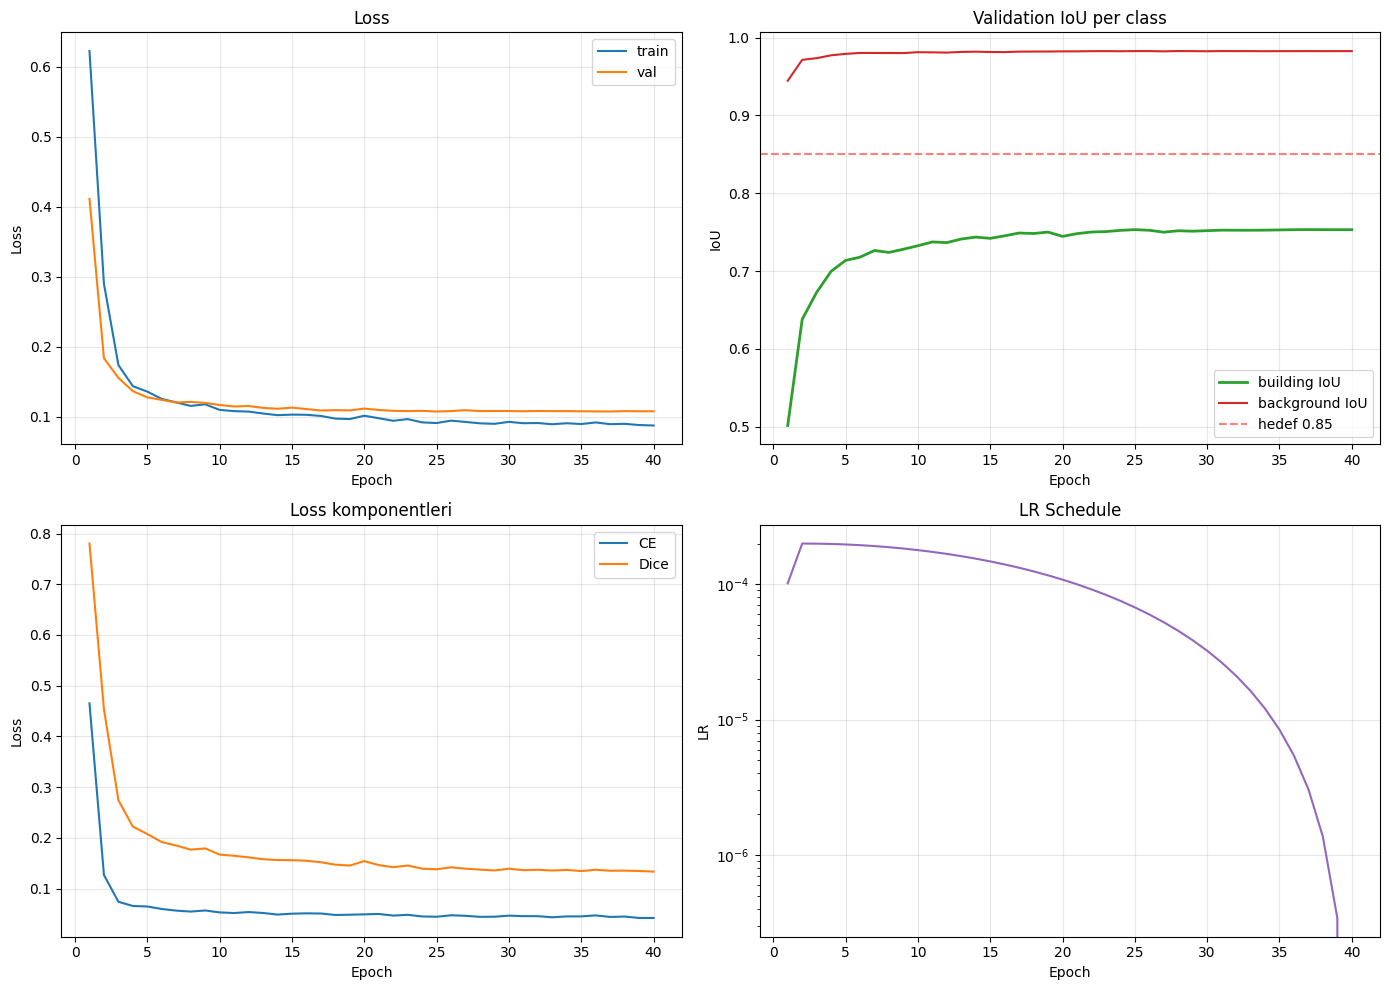


🎨 Tahmin görseli...
✅ Kaydedildi: /content/drive/MyDrive/AFETSONAR/outputs/visualizations/localizer_predictions.png


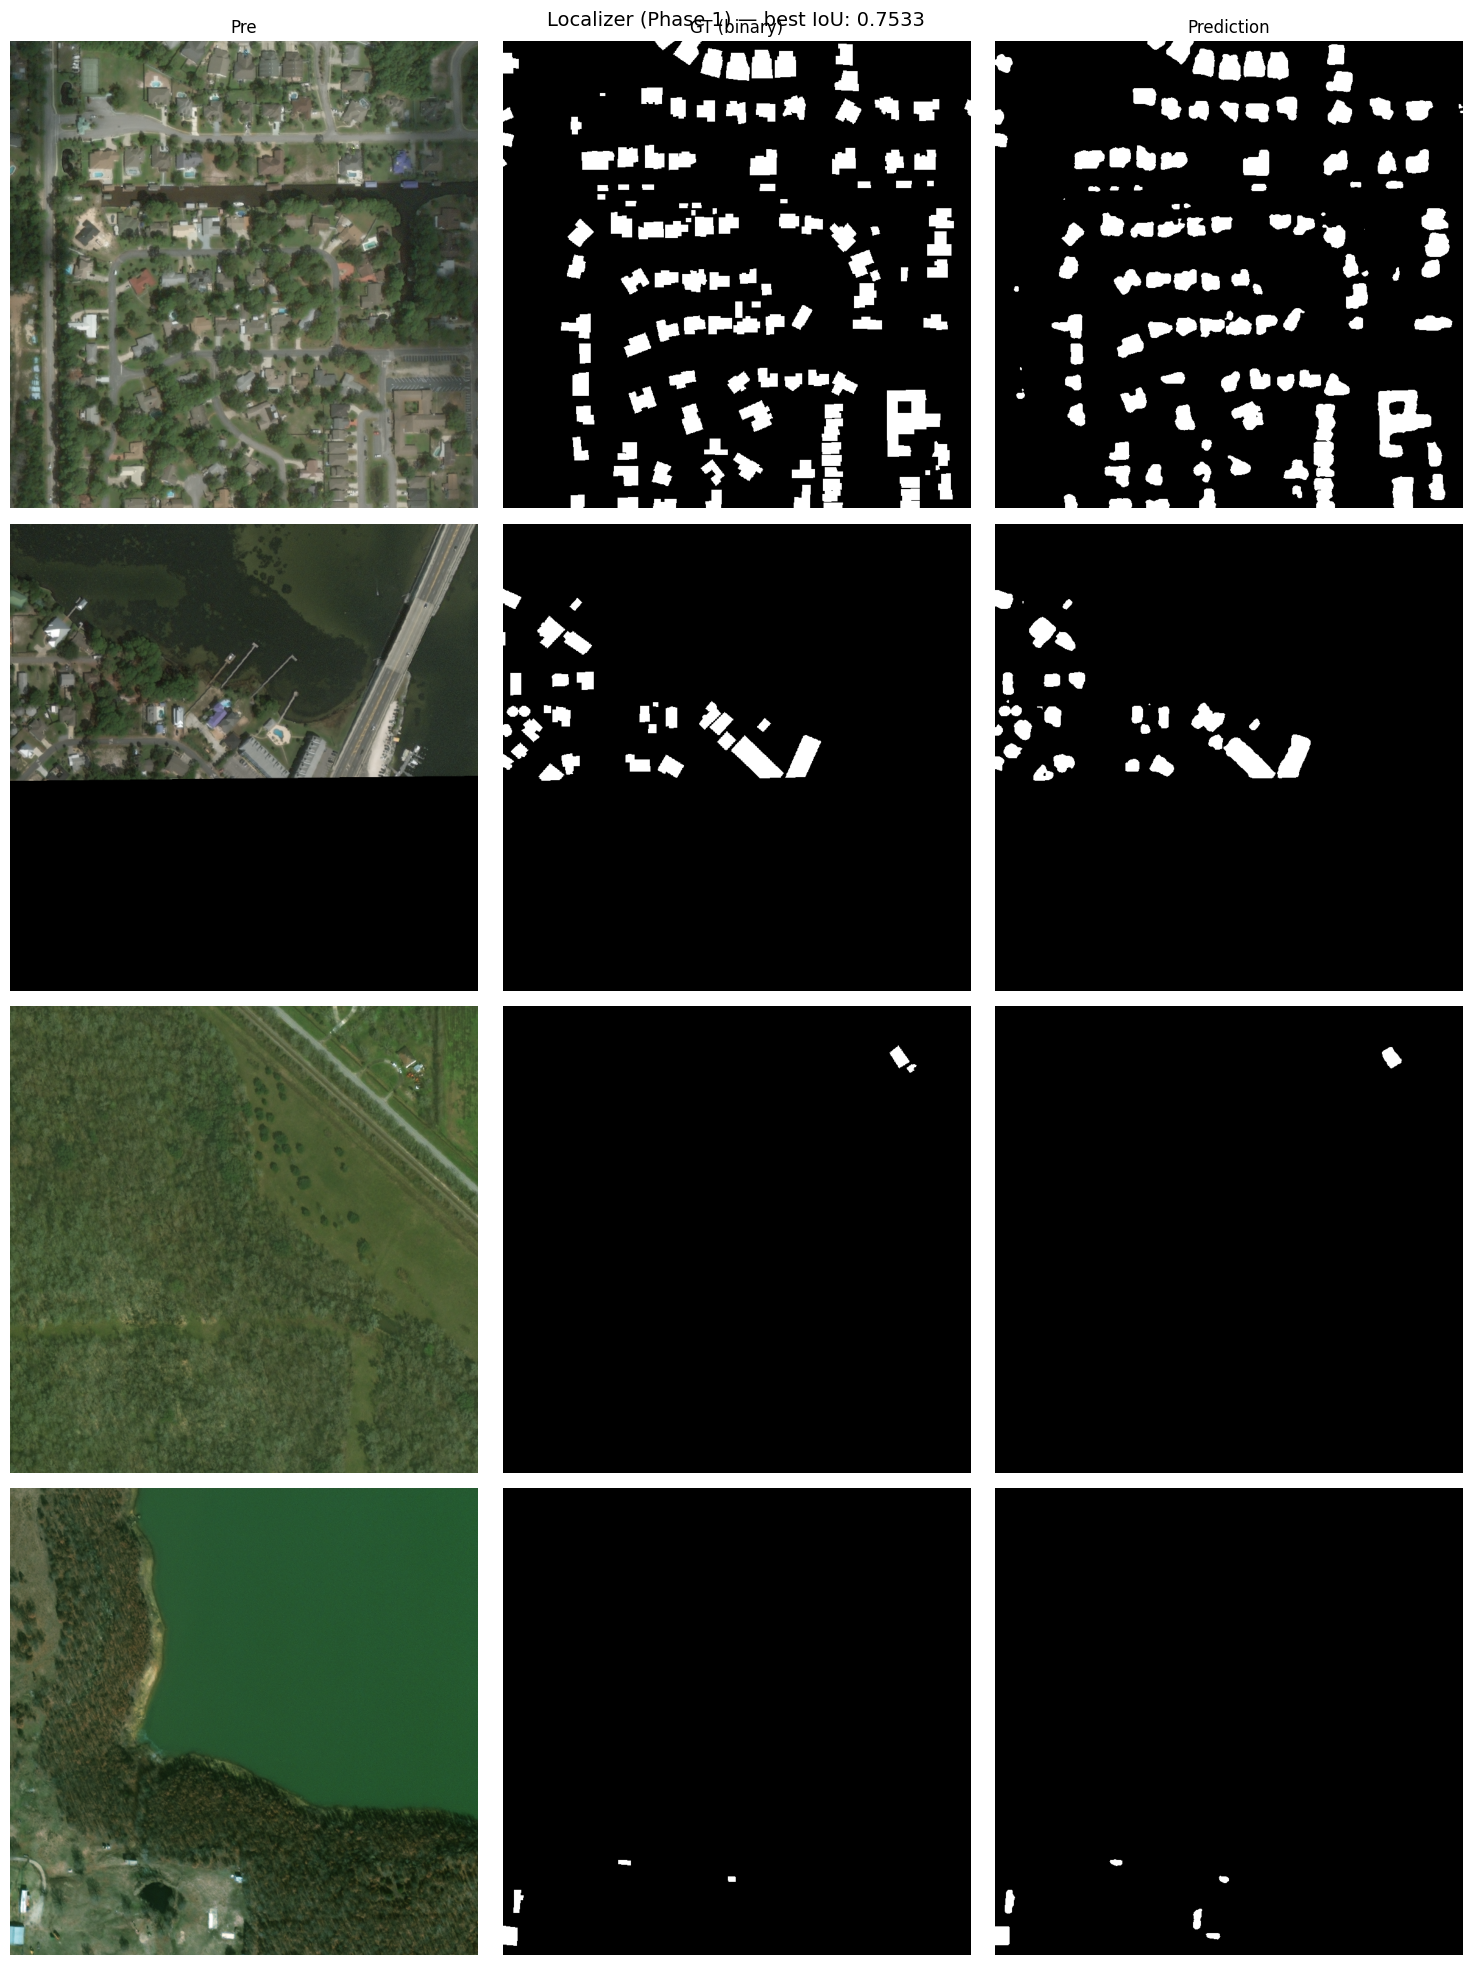

In [7]:
import matplotlib.pyplot as plt
import json

with open(os.path.join(CKPT_TEACHER, "localizer_history.json")) as f:
    history = json.load(f)

epochs = list(range(1, len(history["train_loss"]) + 1))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax = axes[0, 0]
ax.plot(epochs, history["train_loss"], label="train", color="C0")
ax.plot(epochs, history["val_loss"], label="val", color="C1")
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
ax.set_title("Loss")
ax.legend(); ax.grid(alpha=0.3)

ax = axes[0, 1]
ax.plot(epochs, history["val_iou_building"], color="C2", linewidth=2, label="building IoU")
ax.plot(epochs, history["val_iou_bg"], color="C3", label="background IoU")
ax.axhline(y=0.85, color="red", linestyle="--", alpha=0.5, label="hedef 0.85")
ax.set_xlabel("Epoch"); ax.set_ylabel("IoU")
ax.set_title("Validation IoU per class")
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1, 0]
ax.plot(epochs, history["train_ce"], label="CE", color="C0")
ax.plot(epochs, history["train_dice"], label="Dice", color="C1")
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
ax.set_title("Loss komponentleri")
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1, 1]
ax.plot(epochs, history["lr"], color="C4")
ax.set_xlabel("Epoch"); ax.set_ylabel("LR")
ax.set_title("LR Schedule")
ax.set_yscale("log")
ax.grid(alpha=0.3)

plt.tight_layout()
fig_path = os.path.join(OUTPUTS_VIZ, "localizer_training_curves.png")
plt.savefig(fig_path, dpi=100, bbox_inches="tight")
print(f"✅ Kaydedildi: {fig_path}")
plt.show()

# Tahmin görseli
print("\n🎨 Tahmin görseli...")
ckpt = torch.load(os.path.join(CKPT_TEACHER, "localizer_best.pth"),
                  map_location=device, weights_only=False)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

import random
random.seed(42)
sample_indices = random.sample(range(len(val_ds)), 4)

fig, axes = plt.subplots(4, 3, figsize=(15, 20))

for row, idx in enumerate(sample_indices):
    sample = val_ds[idx]
    img_batch = sample["image"].unsqueeze(0).to(device)

    with torch.no_grad():
        with torch.autocast(device_type="cuda", dtype=amp_dtype):
            logits = model(img_batch)
        pred = logits.argmax(dim=1)[0].cpu()

    # Denormalize
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    pre = (sample["image"] * std + mean).permute(1, 2, 0).numpy().clip(0, 1)

    axes[row, 0].imshow(pre)
    axes[row, 0].set_title("Pre" if row == 0 else "")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(sample["mask"].numpy(), cmap="gray", vmin=0, vmax=1)
    axes[row, 1].set_title("GT (binary)" if row == 0 else "")
    axes[row, 1].axis("off")

    axes[row, 2].imshow(pred.numpy(), cmap="gray", vmin=0, vmax=1)
    axes[row, 2].set_title("Prediction" if row == 0 else "")
    axes[row, 2].axis("off")

plt.suptitle(f"Localizer (Phase 1) — best IoU: {ckpt['val_iou_building']:.4f}", fontsize=14)
plt.tight_layout()
pred_path = os.path.join(OUTPUTS_VIZ, "localizer_predictions.png")
plt.savefig(pred_path, dpi=80, bbox_inches="tight")
print(f"✅ Kaydedildi: {pred_path}")
plt.show()

## 🎉 Phase 1 Tamamlandı!

### Ne yaptık?

✅ Building Localization modelini sıfırdan eğittik
✅ SegFormer-B3, 768 resolution, BCE+Dice loss
✅ 40 epoch eğitim
✅ Best model: `localizer_best.pth`

### Sonraki Adım: Phase 2 — Damage Classification

`02_v3_phase2_damage.ipynb` notebook'u:
- SiameseTeacherSegformerV3 modeli inşa edecek
- **`localizer_best.pth`'in encoder weights'ini yükleyecek** (transfer learning)
- Lovász + Dice + Focal combo loss (yeni!)
- Deep supervision (auxiliary heads)
- EMA model averaging
- Tam damage classification (6 sınıf)
- Hedef: mIoU_no_bg ≥ 0.55

Phase 2 için Phase 1 sonuçları yeterli mi?
- IoU ≥ 0.85 → Mükemmel, Phase 2 hızlı convergence
- IoU 0.75-0.85 → İyi, devam et
- IoU < 0.75 → Bana söyle, debug edelim

---

**Calamitas AI · Teknofest 2025 · Phase 1 / 2** 🚀